In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv"
#INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_shapley.csv"
FEATURE_PATH = "../data/bpm_25/8fts_genEL_features.csv"

METRIC_ORDER = ["fitness", "precision", "fscore","cfc", "size", "exectime"]

In [2]:
benchmark = pd.read_csv(INPUT_PATH)
features = pd.read_csv(FEATURE_PATH)
print(benchmark.columns)
print(features.columns)
#benchmark = benchmark.copy()[:5]
#print(features['log'].unique())
#print(benchmark['log'].unique())
feat_bench = features.merge(benchmark, on=['log'])
feat_bench

Index(['log', 'benchtime_inductive', 'cfc_inductive', 'exectime_inductive',
       'fitness_inductive', 'fscore_inductive', 'pnsize_inductive',
       'precision_inductive', 'size_inductive', 'fitness_sm1', 'precision_sm1',
       'fscore_sm1', 'size_sm1', 'cfc_sm1', 'pnsize_sm1', 'exectime_sm1',
       'benchtime_sm1', 'benchtime_ilp', 'cfc_ilp', 'exectime_ilp',
       'fitness_ilp', 'fscore_ilp', 'pnsize_ilp', 'precision_ilp', 'size_ilp'],
      dtype='object')
Index(['activities_q1', 'eventropy_k_block_ratio_3', 'log',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'target_similarity', 'trace_len_kurtosis_hist', 'trace_len_variance'],
      dtype='object')


,activities_q1,eventropy_k_block_ratio_3,log,n_unique_start_activities,ratio_top_5_variants,skewness_variant_occurrence,start_activities_q1,target_similarity,trace_len_kurtosis_hist,trace_len_variance,...,exectime_sm1,benchtime_sm1,benchtime_ilp,cfc_ilp,exectime_ilp,fitness_ilp,fscore_ilp,pnsize_ilp,precision_ilp,size_ilp
0,54.5,NaN,genEL10000_6413_nan_nan_nan_758_31382_nan_nan,NaN,NaN,1.699144,43.50,0.968350,NaN,NaN,...,5.56,7.12,2.01,6.0,0.67,0.999970,0.598802,7.0,0.427356,21.0
1,89.0,NaN,genEL10001_6413_nan_nan_nan_758_nan_-097_nan,NaN,NaN,9.054366,NaN,0.992081,-1.833333,NaN,...,5.09,16.66,10.37,12.0,1.65,0.999980,0.567029,22.0,0.395704,47.0
2,315.0,NaN,genEL10002_6413_nan_nan_nan_758_nan_081_nan,NaN,NaN,11.753222,NaN,0.976671,-1.833333,NaN,...,12.33,12.34,14.89,16.0,3.76,0.999953,0.971141,22.0,0.943944,53.0
3,NaN,NaN,genEL10002_nan_nan_433_nan_nan_17479_97_nan,4.0,NaN,NaN,70.75,0.999359,-1.833333,NaN,...,5.92,21.67,12.41,6.0,0.61,0.999962,0.644041,7.0,0.474980,15.0
4,89.0,NaN,genEL10003_6413_nan_nan_nan_758_nan_259_nan,NaN,NaN,9.054366,NaN,0.991997,-1.833333,NaN,...,6.58,22.76,10.25,12.0,1.45,0.999980,0.567029,22.0,0.395704,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50309,NaN,NaN,genEL_nan_nan_nan_nan_1563_2443_nan_nan,NaN,NaN,16.562458,262.75,0.992565,NaN,NaN,...,19.28,167.65,115.45,12.0,22.76,0.999958,0.579618,8.0,0.408079,25.0
50310,NaN,NaN,genEL_nan_nan_nan_nan_1966_14003_nan_nan,NaN,NaN,20.272901,128.25,0.995114,NaN,NaN,...,30.61,30.61,108.28,12.0,25.21,0.999973,0.730231,11.0,0.575099,39.0
50311,NaN,NaN,genEL_nan_nan_nan_nan_nan_14003_nan_2776,NaN,NaN,NaN,251.00,0.999618,NaN,26.70075,...,12.28,143.37,99.80,17.0,23.12,0.999961,0.486612,7.0,0.321543,32.0
50312,NaN,NaN,genEL_nan_nan_nan_nan_nan_31382_081_nan,NaN,NaN,NaN,319.00,0.999976,0.995171,NaN,...,7.38,7.56,7.34,5.0,7.30,0.999939,0.999969,10.0,1.000000,24.0


In [3]:
INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_benchmark.csv"
FEATURE_PATH = "../data/bpm_25/8fts_genEL_features.csv"

METRIC_ORDER = ["fitness", "precision", "fscore","cfc", "size", "exectime"]
data = pd.read_csv(INPUT_PATH)
feat = pd.read_csv(FEATURE_PATH)
#features = pd.read_csv("../data/bpm_25/8fts_genEL_features.csv")
benchmark = data.copy()
feat = feat.copy()
#print(benchmark.columns)
#print(feat.columns)

#print(benchmark[benchmark['log']=='genEL10000_6413_nan_nan_nan_758_31382_nan_nan'])
#print(feat[feat['log']=='genEL10000_6413_nan_nan_nan_758_31382_nan_nan'])
feat_bench = feat.merge(benchmark, how='inner')
print(feat_bench.shape)

(50314, 34)


In [4]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print(feat.columns)
feature_names = ['trace_len_mean','n_unique_activities','activities_q1', 'entropy_k_block_ratio_3',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'trace_len_kurtosis_hist', 'trace_len_variance']
feature_names = [item for item in feat.columns if 'log' not in item]
feature_names = [item for item in feature_names if 'target_similarity' not in item]
feature_names = ['trace_len_variance', 'trace_len_kurtosis_hist', 'n_unique_start_activities']
metric_names = ['benchtime_inductive', 'cfc_inductive', 'exectime_inductive',
       'fitness_inductive', 'fscore_inductive', 'pnsize_inductive',
       'precision_inductive', 'size_inductive', 'fitness_sm1', 'precision_sm1',
       'fscore_sm1', 'size_sm1', 'cfc_sm1', 'pnsize_sm1', 'exectime_sm1',
       'benchtime_sm1', 'benchtime_ilp', 'cfc_ilp', 'exectime_ilp',
       'fitness_ilp', 'fscore_ilp', 'pnsize_ilp', 'precision_ilp', 'size_ilp']
metric_names = [item for item in benchmark.columns if 'log' not in item]
#metric_names = ['fscore_ilp', 'cfc_ilp', 'size_ilp']

#scaler = StandardScaler()
#feat_bench[feature_names] = scaler.fit_transform(feat_bench[feature_names])
feat_bench.columns

Index(['activities_q1', 'eventropy_k_block_ratio_3', 'log',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'target_similarity', 'trace_len_kurtosis_hist', 'trace_len_variance'],
      dtype='object')


Index(['activities_q1', 'eventropy_k_block_ratio_3', 'log',
       'n_unique_start_activities', 'ratio_top_5_variants',
       'skewness_variant_occurrence', 'start_activities_q1',
       'target_similarity', 'trace_len_kurtosis_hist', 'trace_len_variance',
       'benchtime_inductive', 'cfc_inductive', 'exectime_inductive',
       'fitness_inductive', 'fscore_inductive', 'pnsize_inductive',
       'precision_inductive', 'size_inductive', 'fitness_sm1', 'precision_sm1',
       'fscore_sm1', 'size_sm1', 'cfc_sm1', 'pnsize_sm1', 'exectime_sm1',
       'benchtime_sm1', 'benchtime_ilp', 'cfc_ilp', 'exectime_ilp',
       'fitness_ilp', 'fscore_ilp', 'pnsize_ilp', 'precision_ilp', 'size_ilp'],
      dtype='object')

['trace_len_variance', 'trace_len_kurtosis_hist', 'n_unique_start_activities'] benchtime_inductive


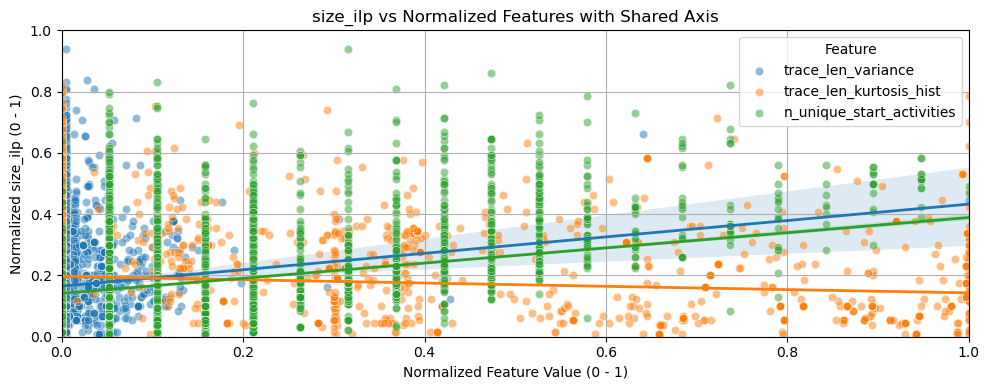

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_linreg_metric(df, feature_names, metric):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    colors = ['tab:orange', 'tab:blue']
    colors = sns.color_palette("tab10", n_colors=len(feature_names))

    # Normalize the metric (y-axis)
    metric_values = df[metric]
    y_min, y_max = metric_values.min(), metric_values.max()
    df['_normalized_metric'] = (metric_values - y_min) / (y_max - y_min)

    for feature, color in zip(feature_names, colors):
        # Filter valid data (no NaNs)
        valid_mask = df[feature].notna() & df[metric].notna()
        x_valid_raw = df.loc[valid_mask, feature]
        y_valid_norm = df.loc[valid_mask, '_normalized_metric']

        # Normalize the feature (x-axis)
        x_min, x_max = x_valid_raw.min(), x_valid_raw.max()
        x_valid_norm = (x_valid_raw - x_min) / (x_max - x_min)

        # Scatter plot
        sns.scatterplot(
            x=x_valid_norm,
            y=y_valid_norm,
            ax=ax,
            alpha=0.5,
            label=feature,
            color=color
        )

        # Regression line (on normalized data)
        sns.regplot(
            x=x_valid_norm,
            y=y_valid_norm,
            scatter=False,
            ax=ax,
            color=color,
            line_kws={'linewidth': 2},
            truncate=False
        )

    ax.set_xlabel('Normalized Feature Value (0 - 1)')
    ax.set_ylabel(f'Normalized {metric} (0 - 1)')
    ax.grid(True)
    plt.title(f'{metric} vs Normalized Features with Shared Axis')
    plt.legend(title='Feature')
    plt.tight_layout()
    plt.show()
    
print(feature_names, metric_names[0])#, feat_bench.columns)
#print(feat_bench.columns)
plot_linreg_metric(feat_bench, feature_names,  metric_names[-1])
#feat_bench

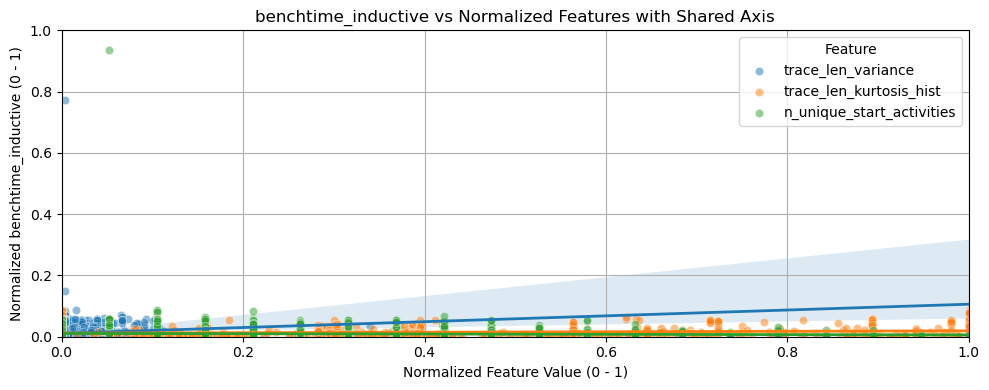

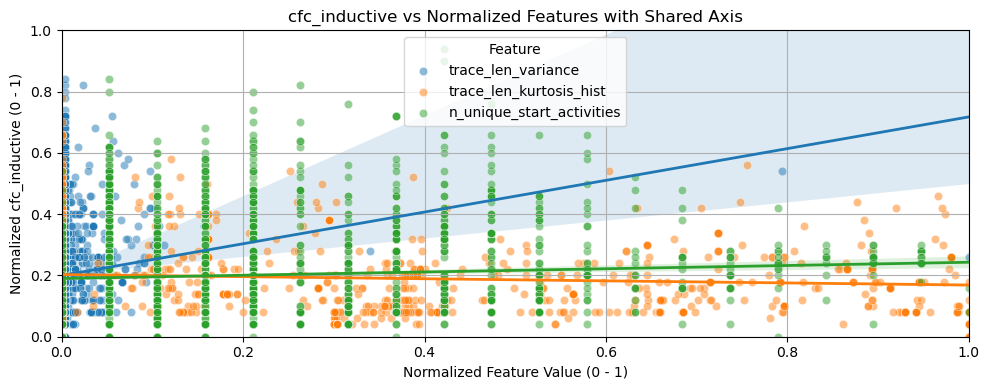

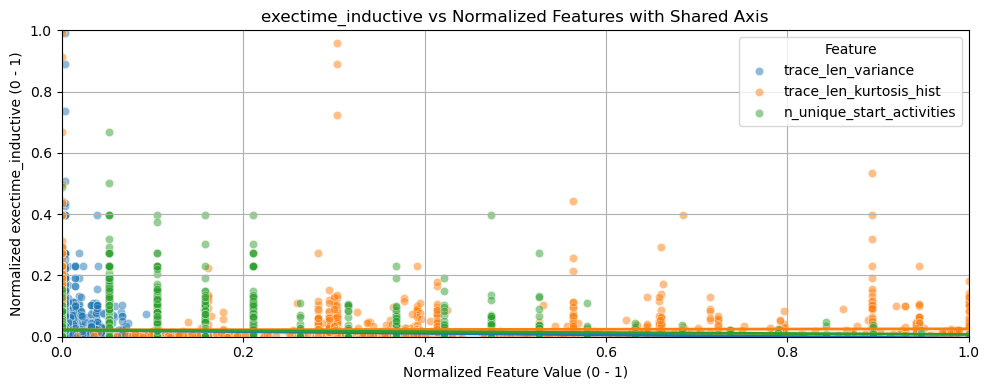

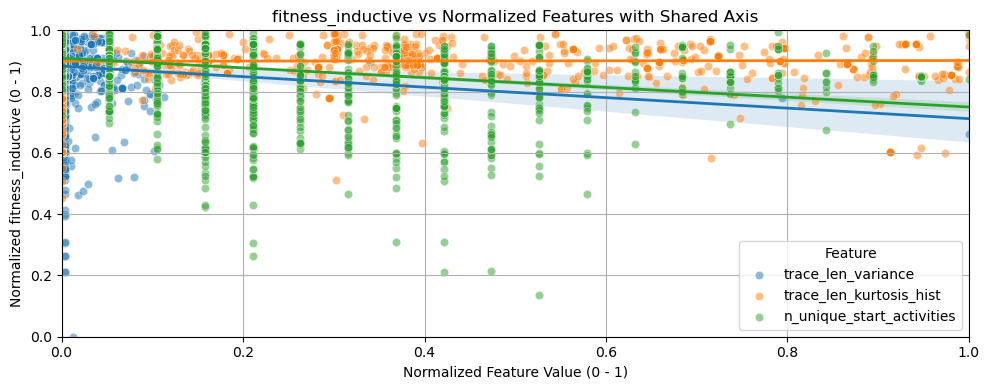

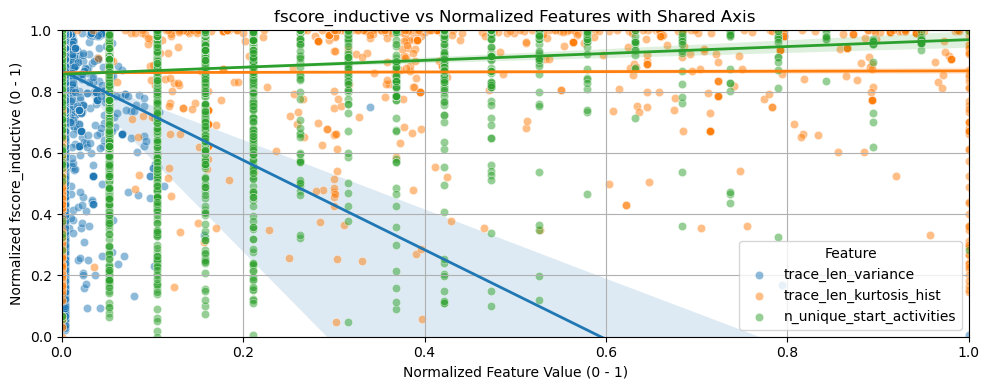

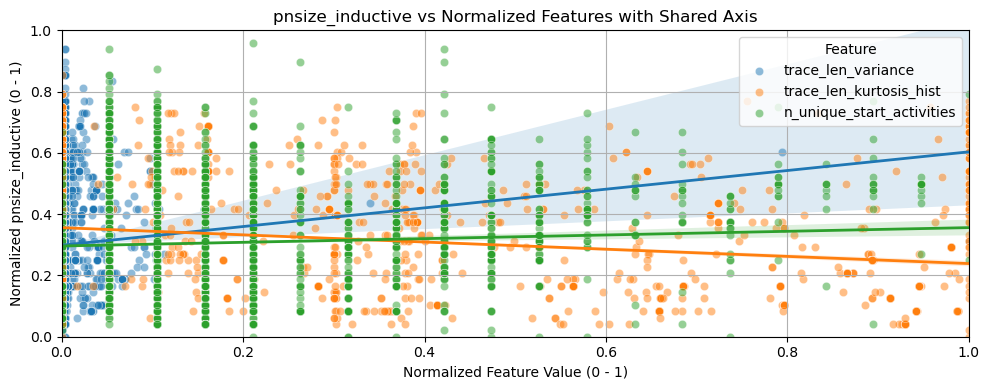

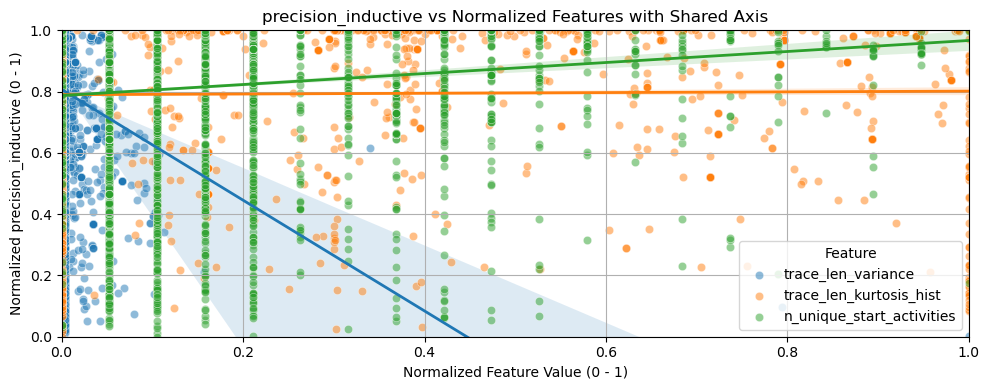

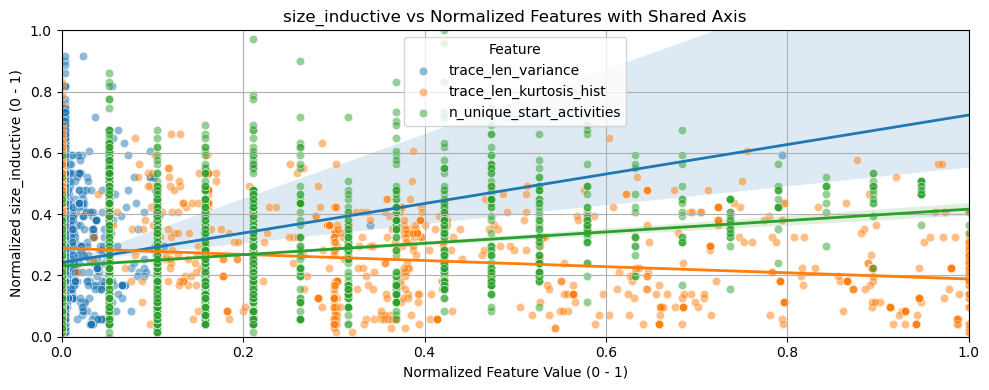

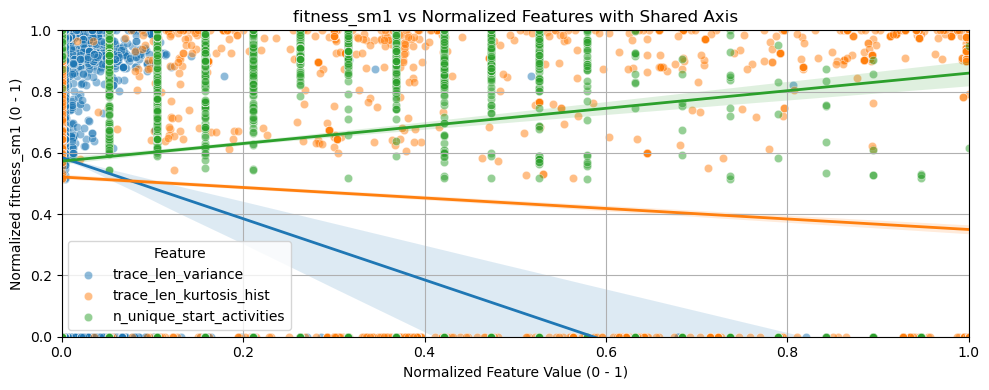

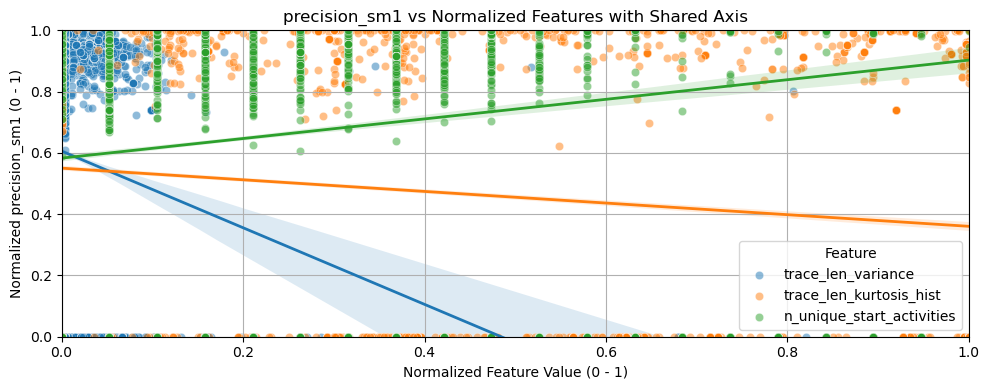

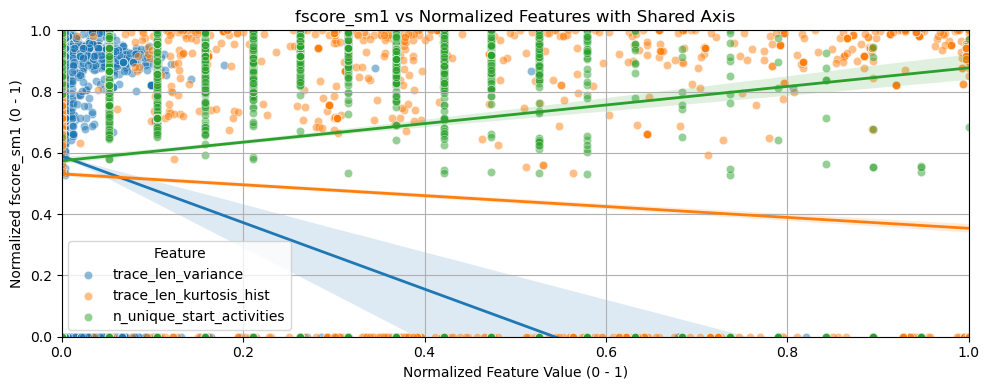

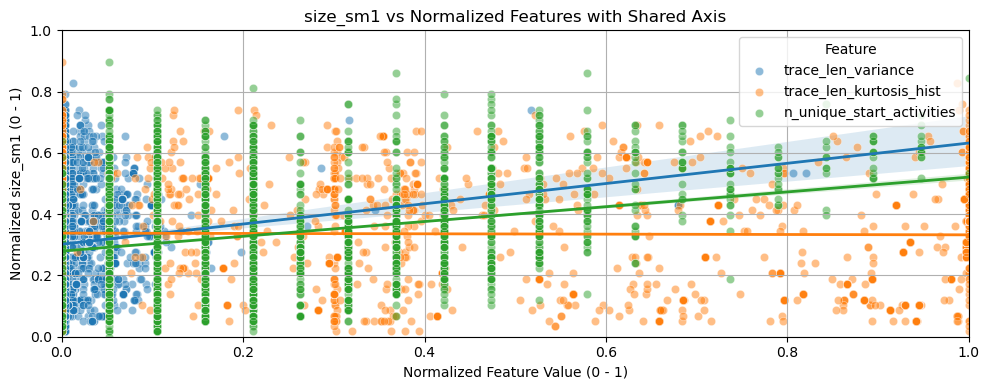

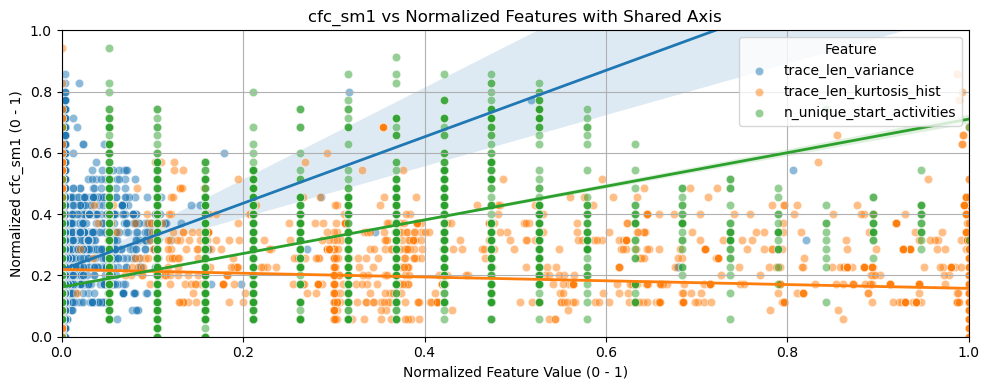

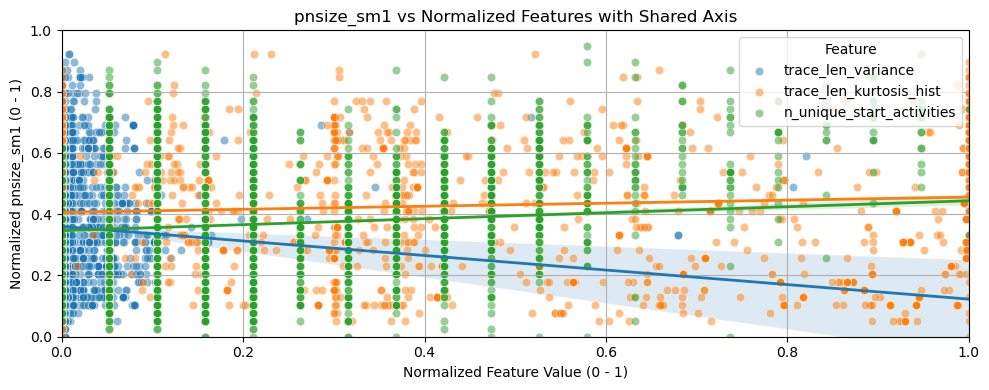

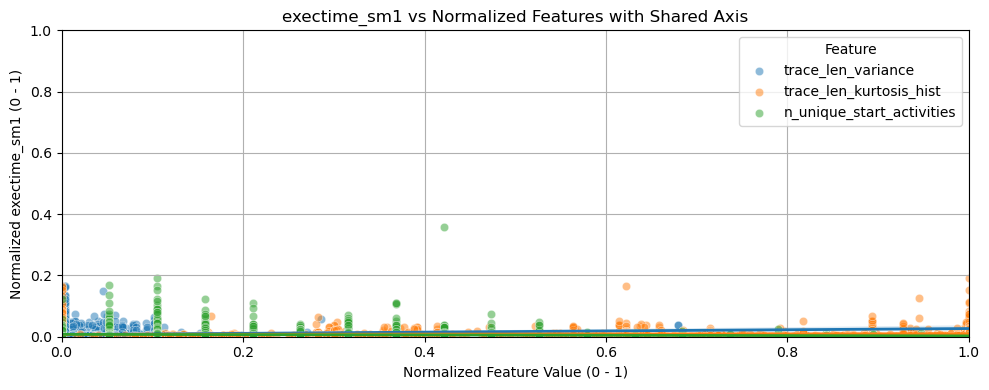

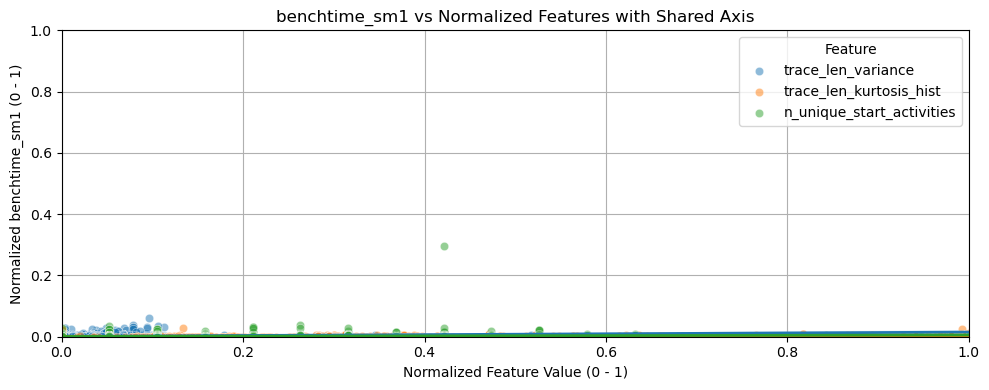

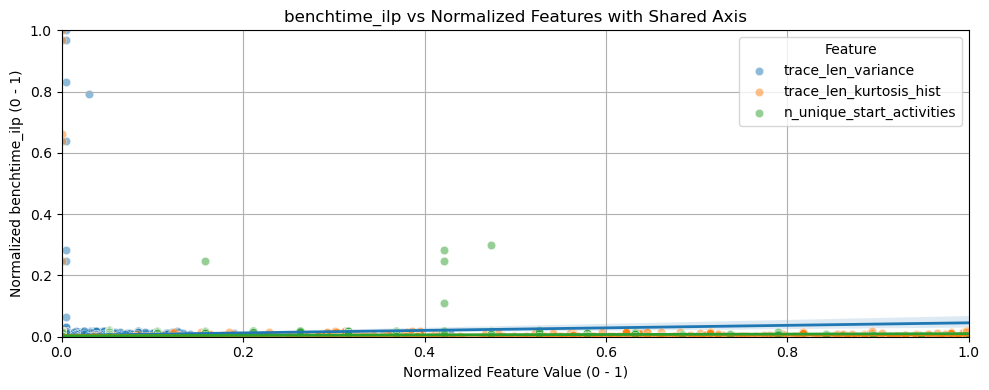

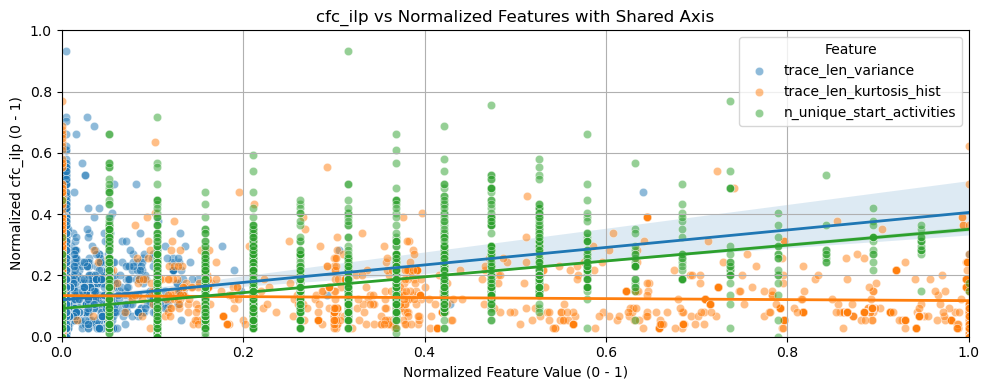

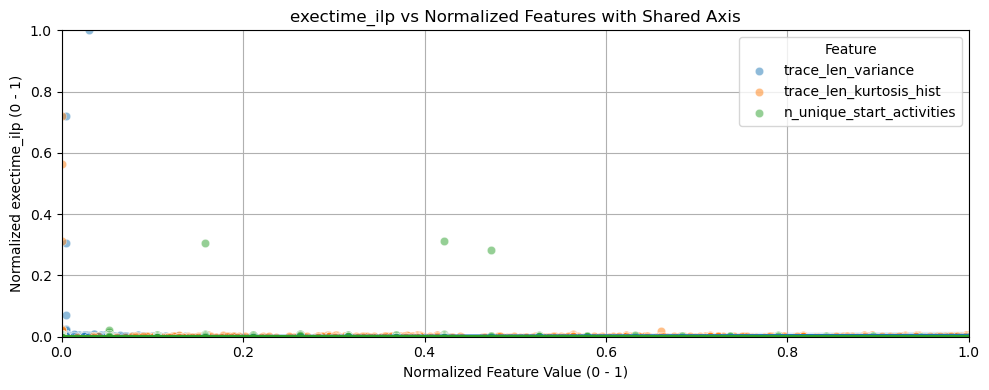

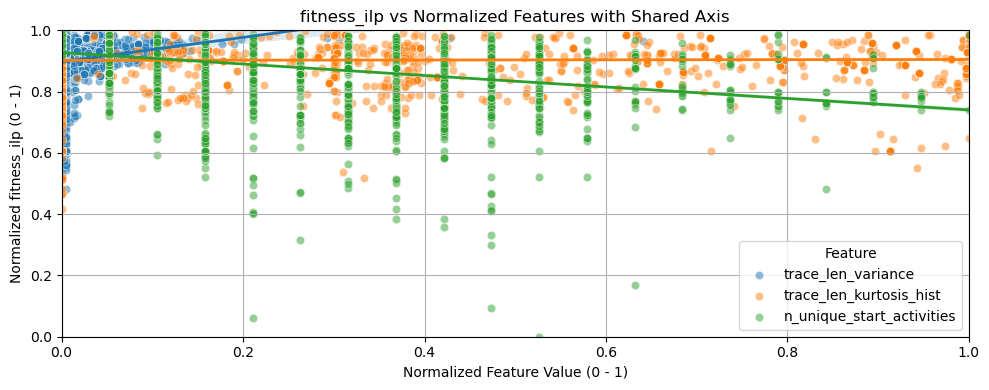

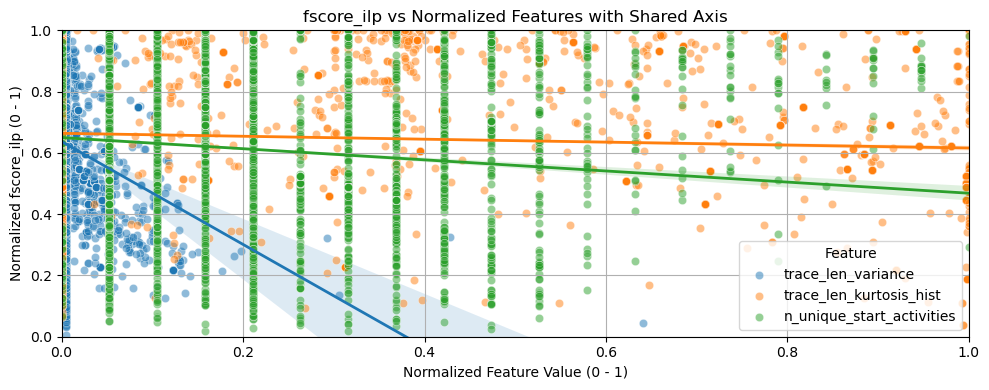

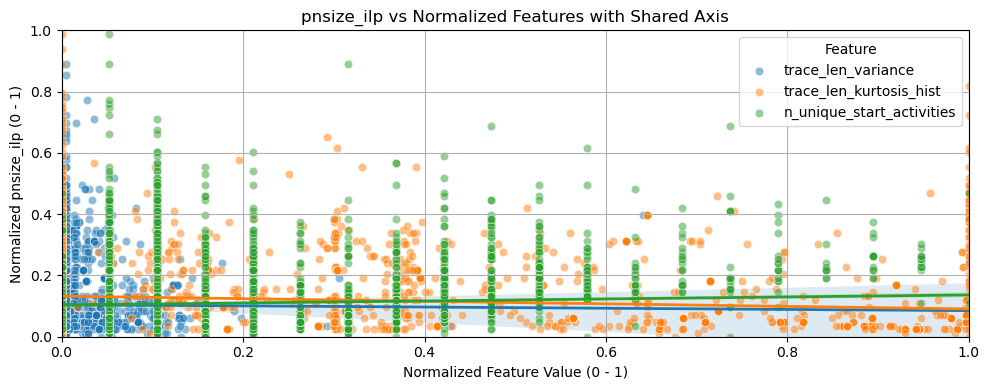

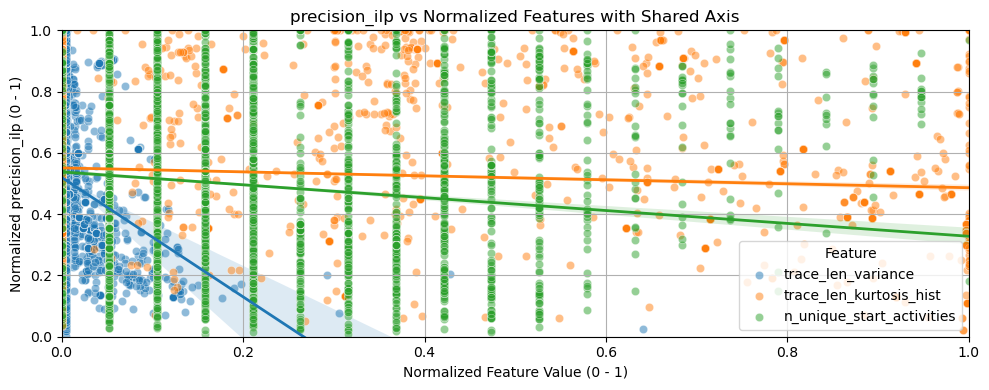

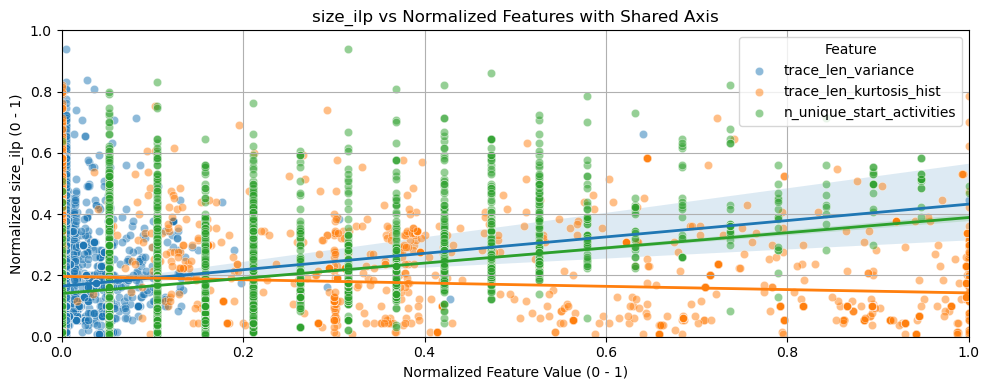

In [6]:
for metric in metric_names: 
    plot_linreg_metric(feat_bench, feature_names, metric)

In [16]:
INPUT_PATH = "../../gedi/data/BaselineED_bench.csv"
FEATURE_PATH = "../../gedi/data/BaselineED_feat.csv"
FEATURE_PATH = "../data/bpm_25/bpic_features_p.csv"

benchmark = pd.read_csv(INPUT_PATH)
feat = pd.read_csv(FEATURE_PATH)
print(benchmark.columns)
print(feat.columns)
#feat.rename(columns={'ratio_unique_traces_per_trace': 'ratio_variants_per_number_of_traces'}, inplace=True)
#feat[['log', 'ratio_variants_per_number_of_traces','ratio_most_common_variant','ratio_top_10_variants']].head()
feat_bench = feat.merge(benchmark, how='inner')
#feat_bench

Index(['log', 'fitness_ilp', 'precision_ilp', 'fscore_ilp', 'size_ilp',
       'pnsize_ilp', 'cfc_ilp', 'fitness_imf', 'precision_imf', 'fscore_imf',
       'size_imf', 'pnsize_imf', 'cfc_imf', 'fitness_heu', 'precision_heu',
       'fscore_heu', 'size_heu', 'pnsize_heu', 'cfc_heu'],
      dtype='object')
Index(['log', 'n_traces', 'n_unique_traces', 'ratio_unique_traces_per_trace',
       'trace_len_min', 'trace_len_max', 'trace_len_mean', 'trace_len_median',
       'trace_len_mode', 'trace_len_std',
       ...
       'entropy_knn_5', 'entropy_knn_7', 'variant_entropy',
       'normalized_variant_entropy', 'sequence_entropy',
       'normalized_sequence_entropy', 'sequence_entropy_linear_forgetting',
       'normalized_sequence_entropy_linear_forgetting',
       'sequence_entropy_exponential_forgetting',
       'normalized_sequence_entropy_exponential_forgetting'],
      dtype='object', length=101)


In [17]:
metric = 'size_ilp'
scaler = MinMaxScaler()
feat_bench_clean = feat_bench.dropna(subset=feature_names + [metric])

X_scaled = scaler.fit_transform(feat_bench_clean[feature_names])
feat_scaled = pd.DataFrame(X_scaled, columns=feature_names)
feat_scaled[metric] = feat_bench_clean[metric].values

KeyError: ['nusa', 'tlv']

In [18]:
df = feat_scaled.copy()
print(df[feature].min(), df[feature].max())

columns_sel = ['log','cfc_heu']+feature_names
print(columns_sel)
#print(feat_bench[columns_sel])
#df[columns_sel].head()

0.0 0.9999999999999999
['log', 'cfc_heu', 'nusa', 'tlv']


In [11]:
for feature in feature_names:
    print(f"{feature} min: {df[feature].min()}, max: {df[feature].max()}")
print(f"{metric} min: {df[metric].min()}, max: {df[metric].max()}")


trace_len_variance min: 0.0, max: 0.9999999999999999
trace_len_kurtosis_hist min: 0.0, max: 1.0
n_unique_start_activities min: 0.0, max: 0.9999999999999999
size_ilp min: 4.0, max: 270.0


KeyError: ['benchtime_inductive']

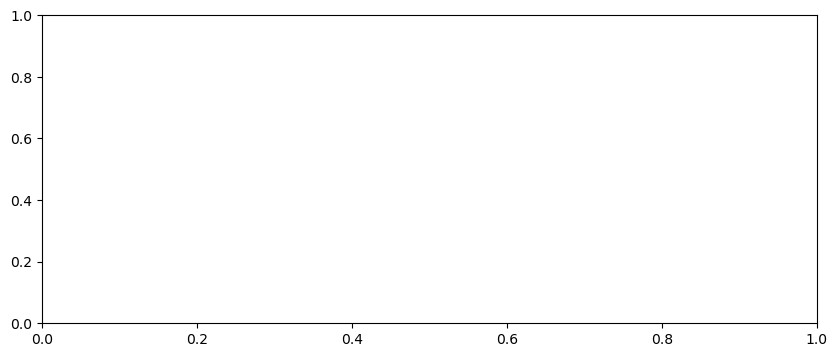

In [12]:
import matplotlib.lines as mlines

for metric in metric_names:
    fig, ax = plt.subplots(figsize=(10, 4))
    
    feat_bench_clean = feat_bench.dropna(subset=feature_names + [metric, 'log'])
    
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(feat_bench_clean[feature_names])
    feat_scaled = pd.DataFrame(X_scaled, columns=feature_names)
    feat_scaled[metric] = feat_bench_clean[metric].values
    feat_scaled['log'] = feat_bench_clean['log'].values

    colors = sns.color_palette("tab10", n_colors=len(feature_names))
    legend_handles = []
    
    for feature, color in zip(feature_names, colors):
        sns.regplot(
            x=feat_scaled[feature],
            y=feat_scaled[metric],
            scatter_kws={'alpha': 0.5, 'color': color},
            line_kws={'color': color, 'linewidth': 2},
            ax=ax
        )
        
        for i in range(len(feat_scaled)):
            x_val = feat_scaled[feature].iloc[i]
            y_val = feat_scaled[metric].iloc[i]
            label = str(feat_scaled['log'].iloc[i])
            
            if False:#np.isfinite(x_val) and np.isfinite(y_val):
                ax.text(
                    x_val,
                    y_val,
                    label,
                    fontsize=7,
                    alpha=0.7,
                    #color=color,
                    ha='left',
                    va='bottom'
                )
        
        # Create a Line2D object for the legend with a thin line matching the regression line
        line_handle = mlines.Line2D([], [], color=color, linewidth=2, label=feature)
        legend_handles.append(line_handle)

    ax.set_xlabel('Normalized Feature Value (0 - 1)')
    ax.set_ylabel(metric)
    ax.set_title(f'Linear Fit: {metric} vs Normalized Features')
    ax.grid(True)
    ax.legend(handles=legend_handles, title='Feature')
    plt.tight_layout()
    plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

INPUT_PATH = "../data/bpm_25/8fts_3miners_ind_ilp_sm1_shapley.csv"

METRIC_ORDER = ["fitness", "precision", "fscore","cfc", "size", "exectime"]
data = pd.read_csv(INPUT_PATH)
#features = pd.read_csv("../data/bpm_25/8fts_genEL_features.csv")
shapley = data.copy()
shapley['feature_name'].unique()
shapley.head()

,algorithm,metric,feature_name,feature_value,shapley_value
0,inductive,benchtime,aq1,6413,3.458333
1,inductive,benchtime,svo,758,2.273333
2,inductive,benchtime,tlv,2776,16.348333
3,inductive,benchtime,aq1,6413,-46.155000
4,inductive,benchtime,svo,758,-42.620000


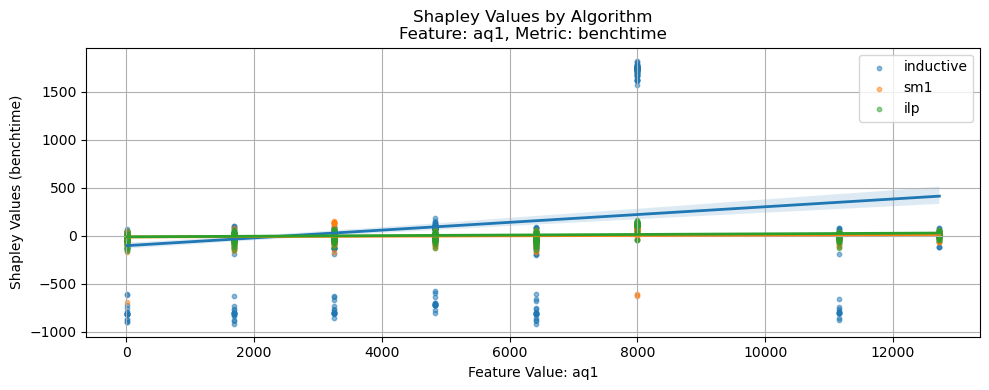

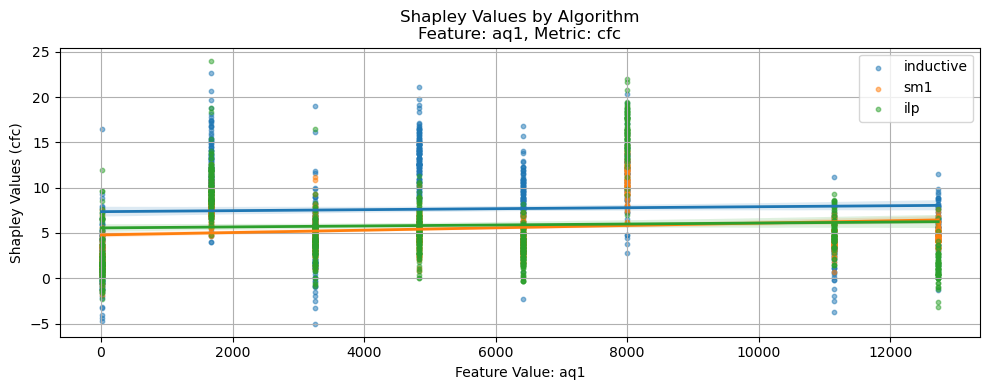

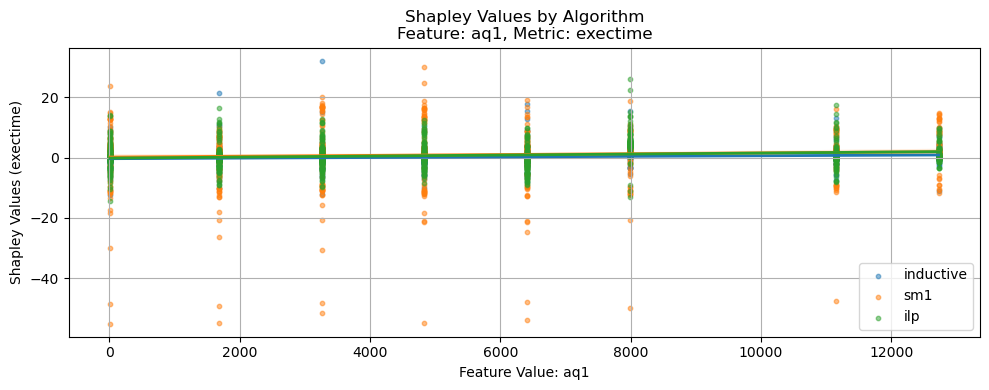

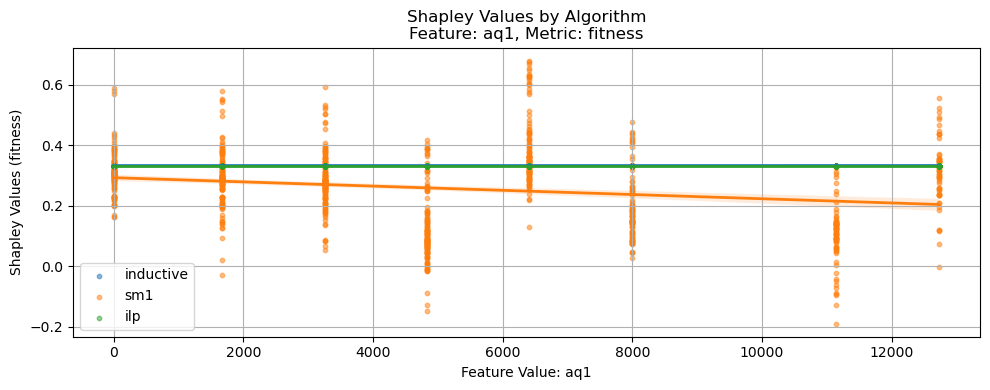

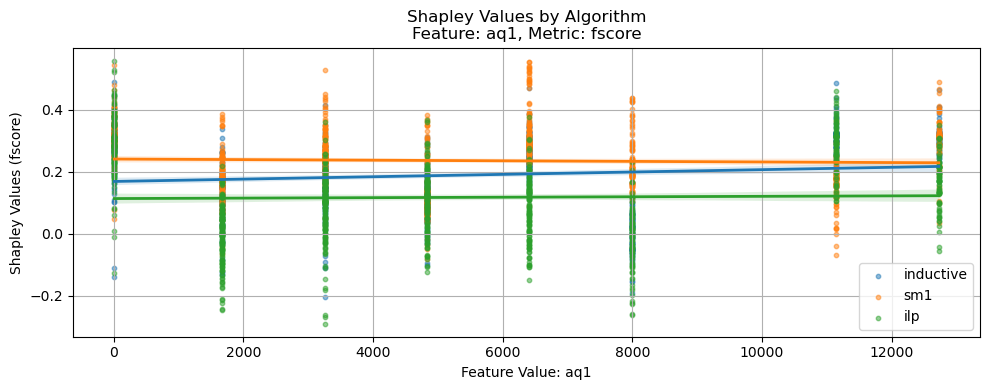

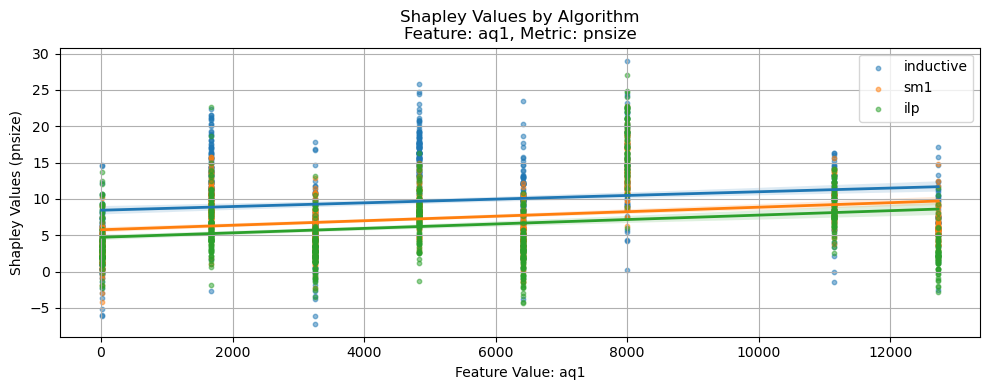

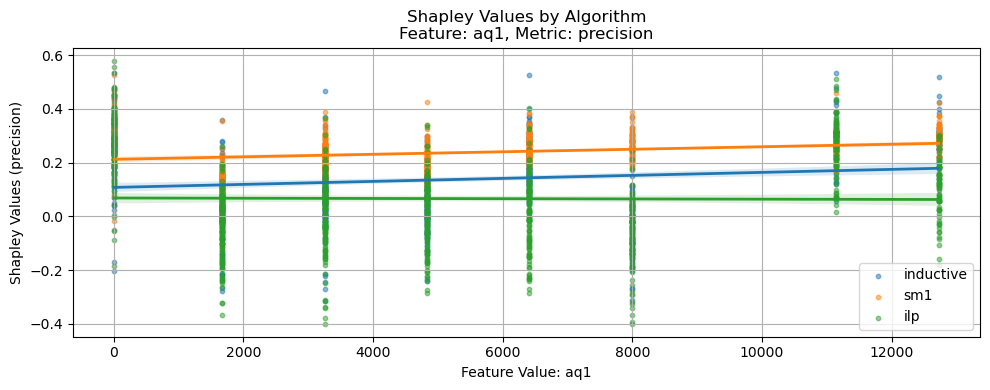

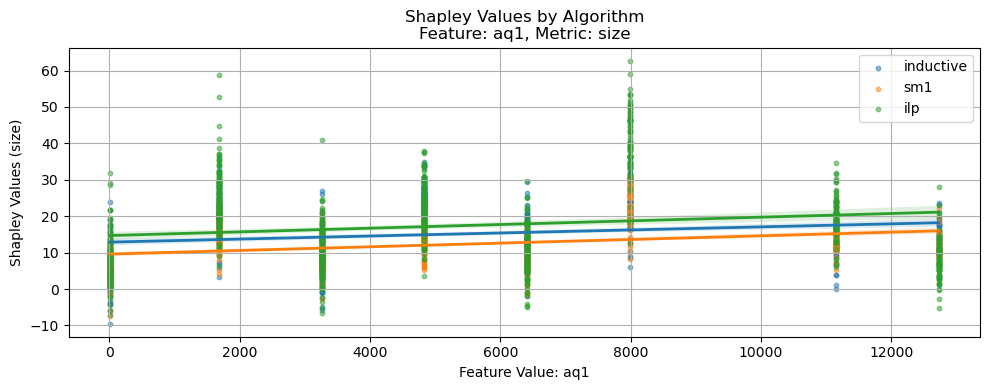

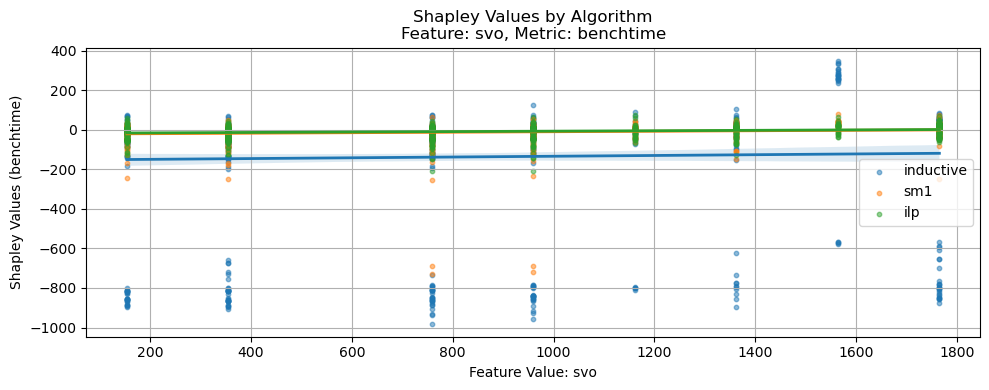

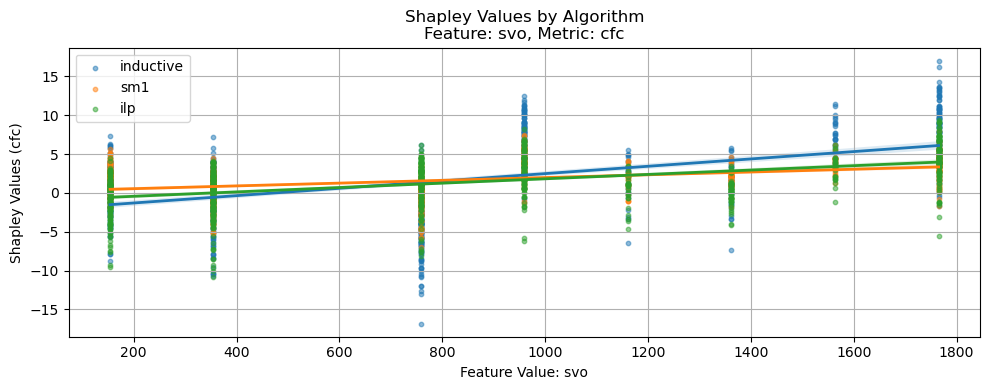

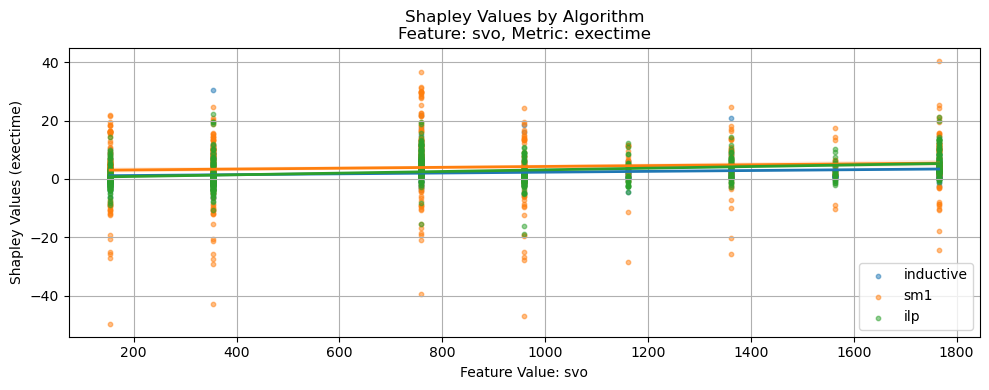

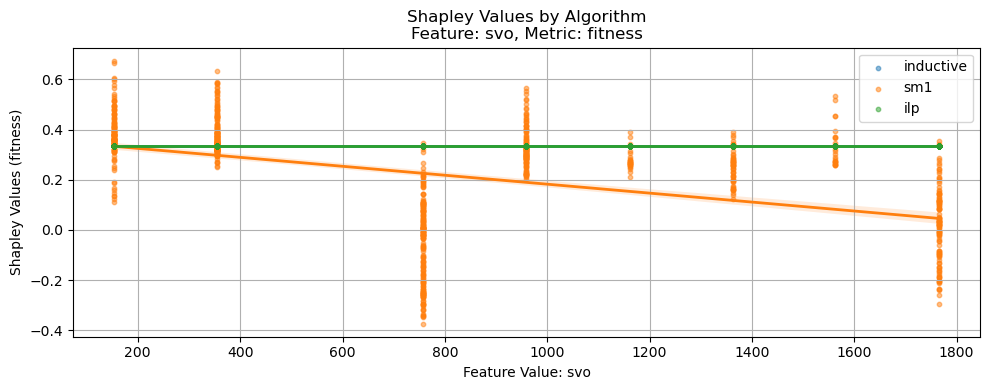

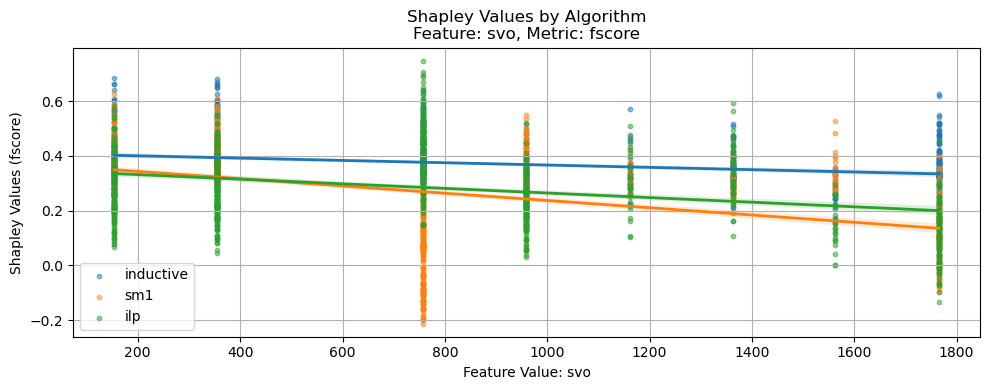

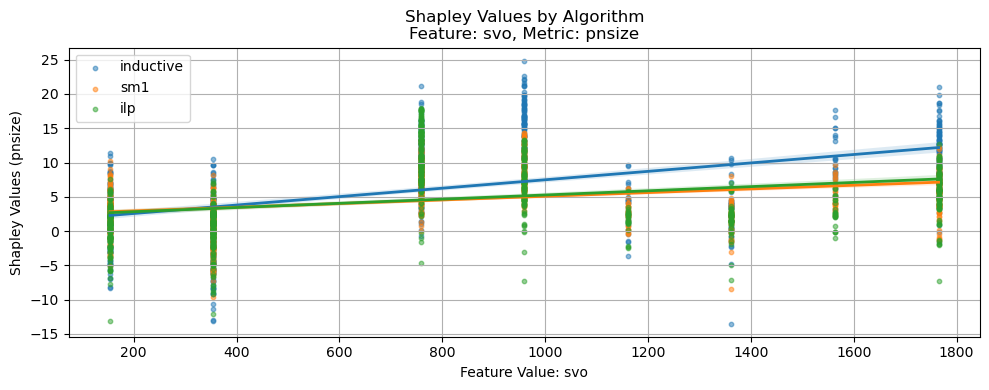

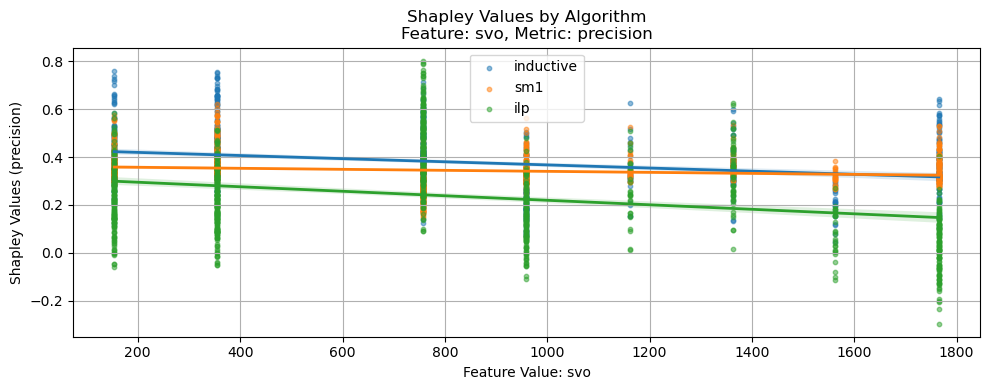

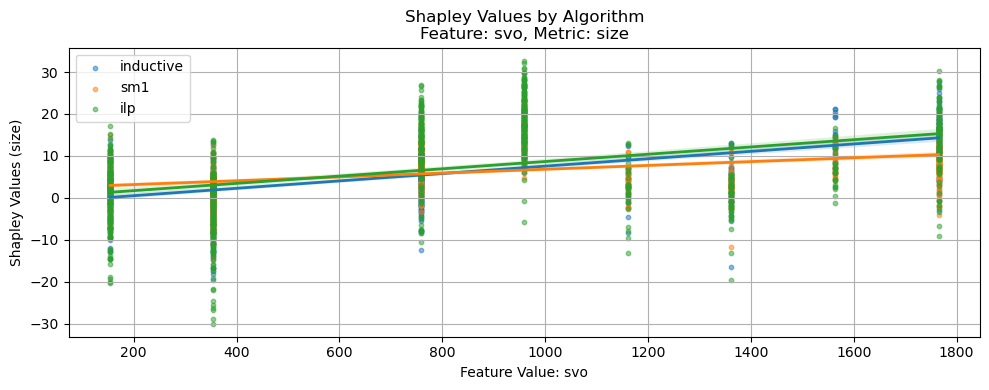

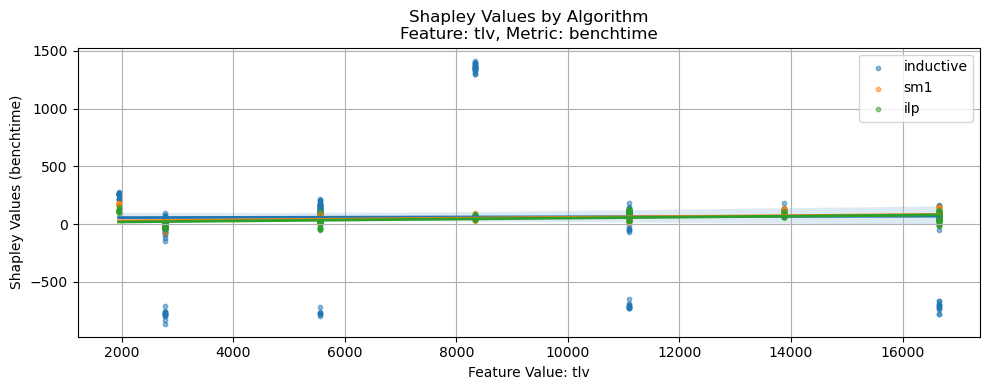

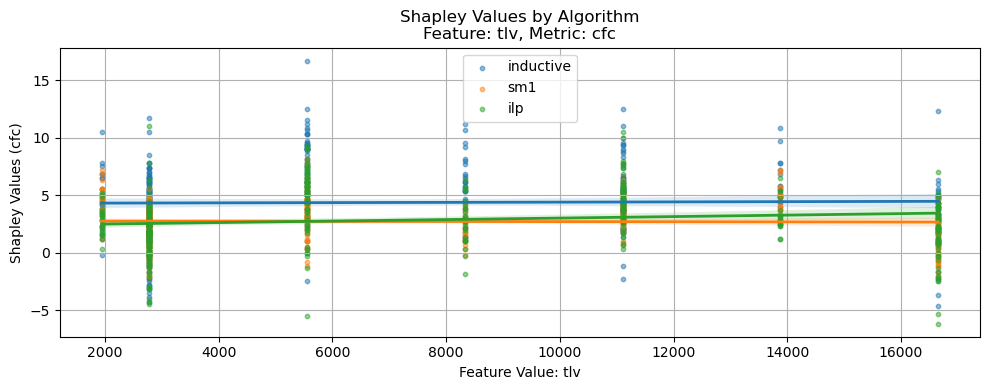

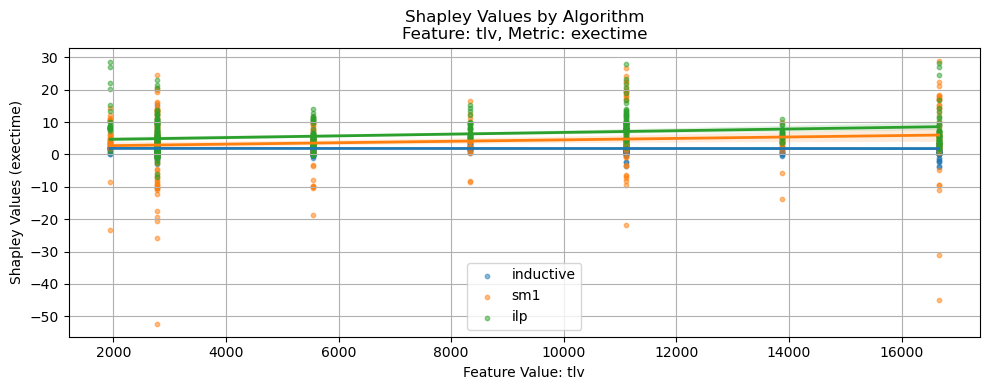

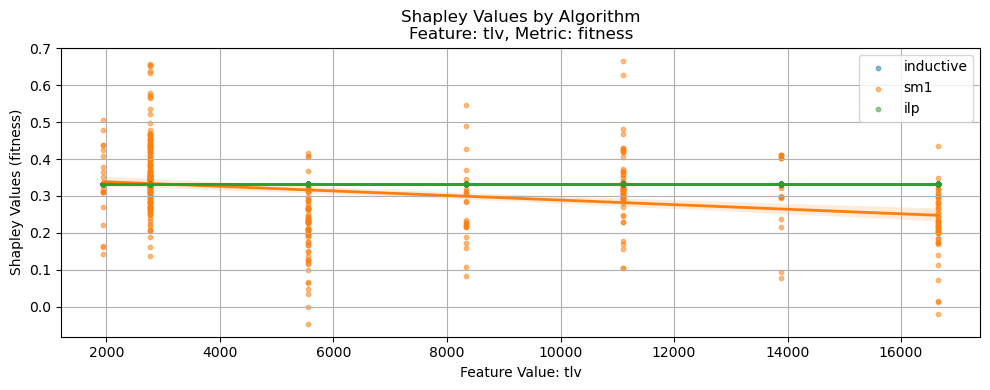

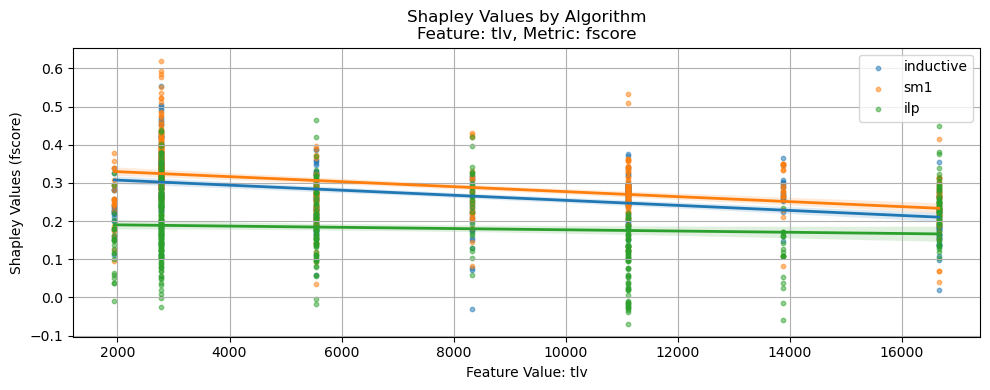

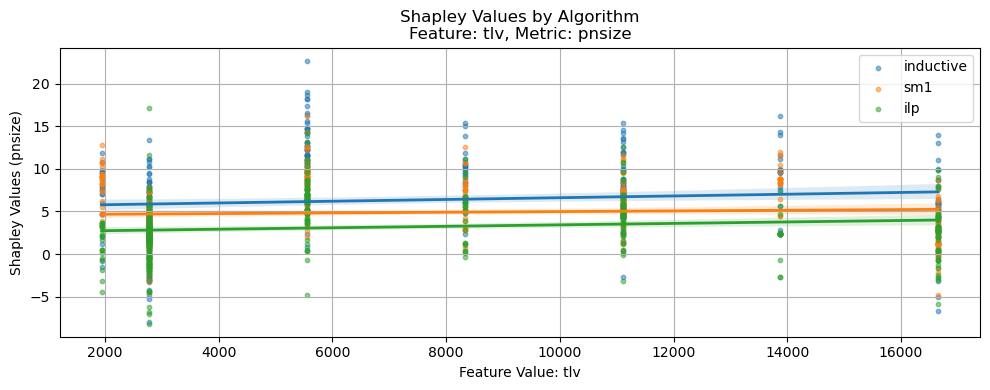

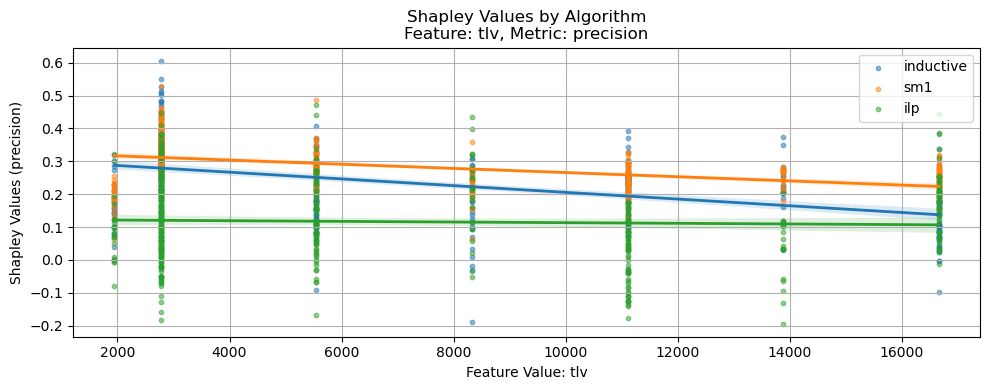

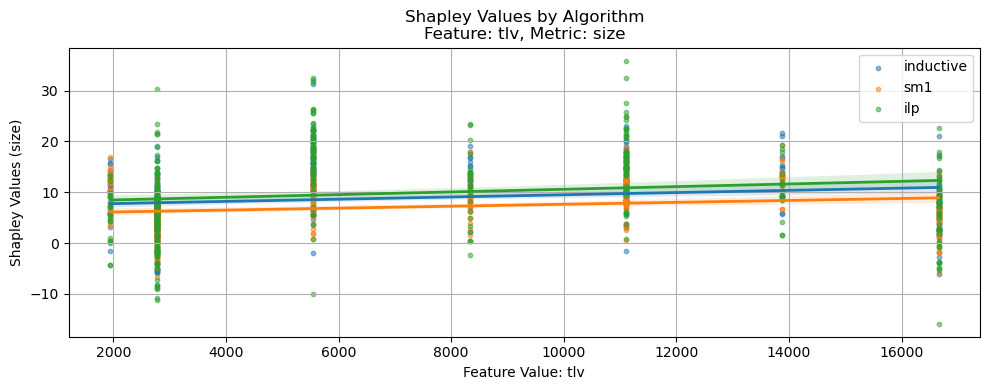

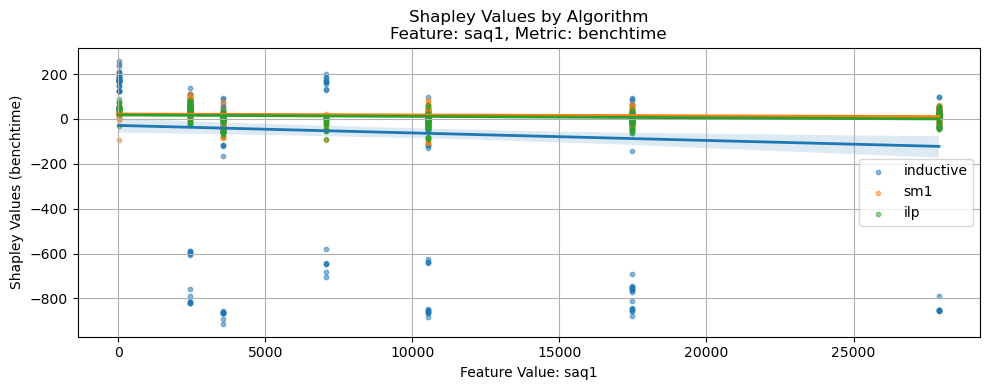

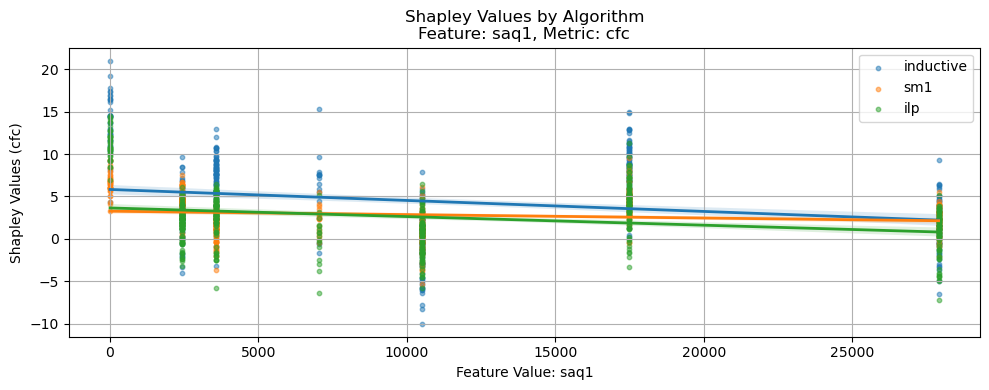

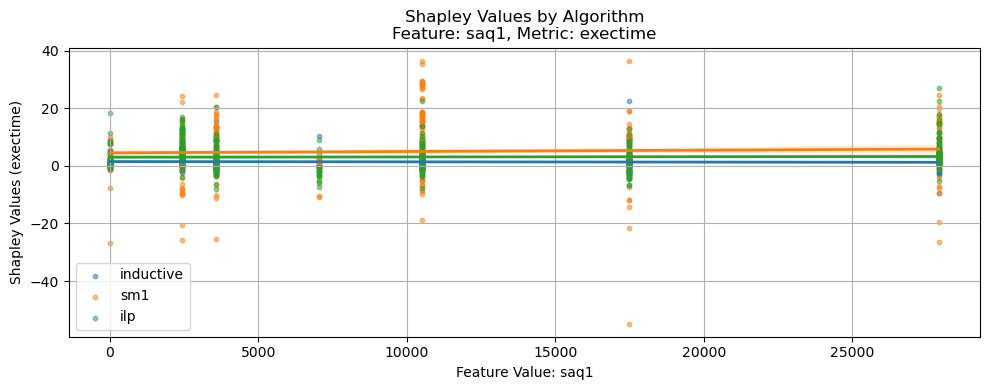

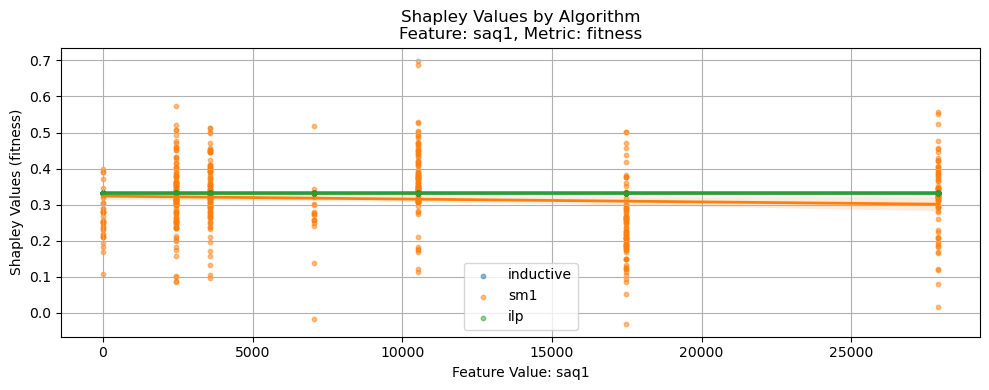

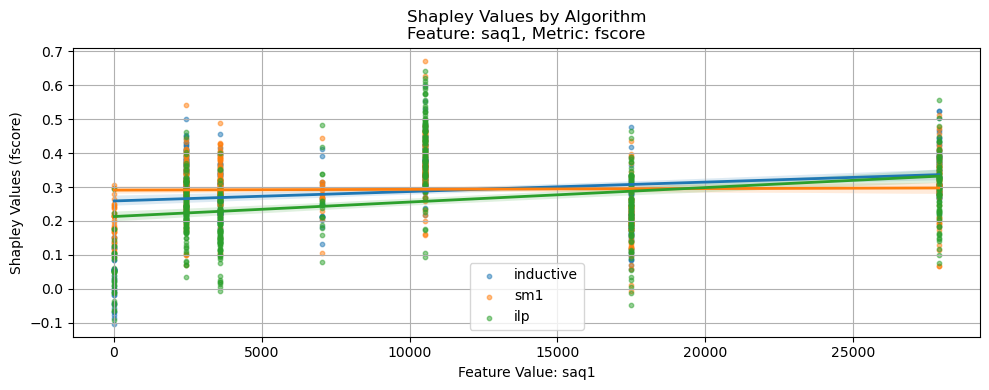

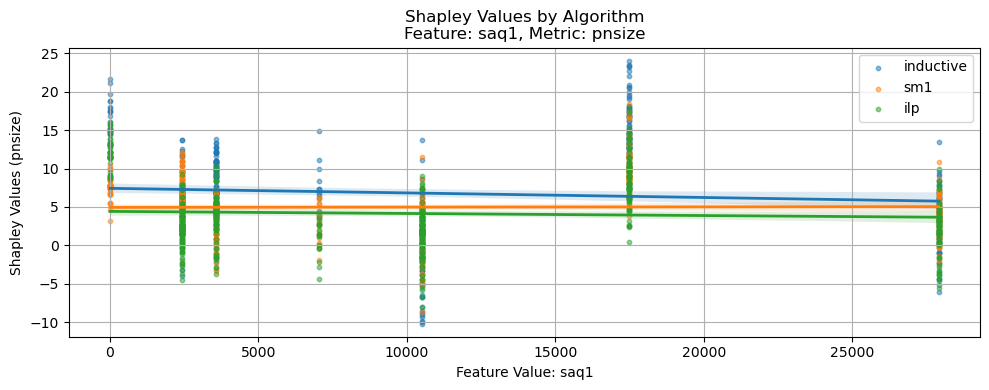

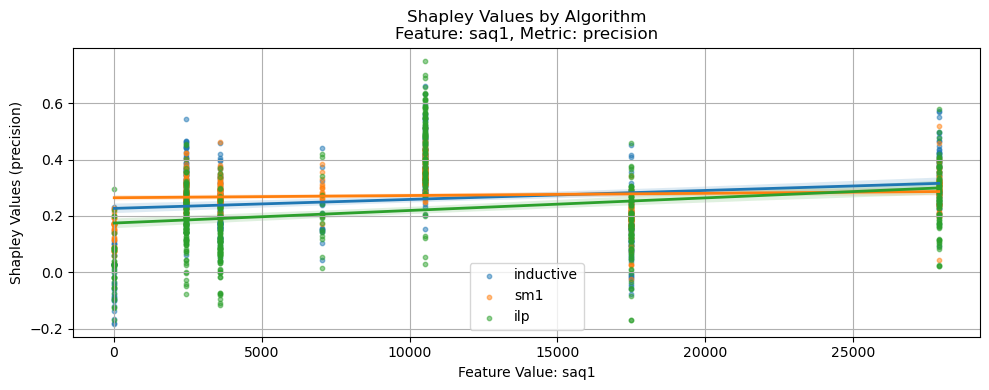

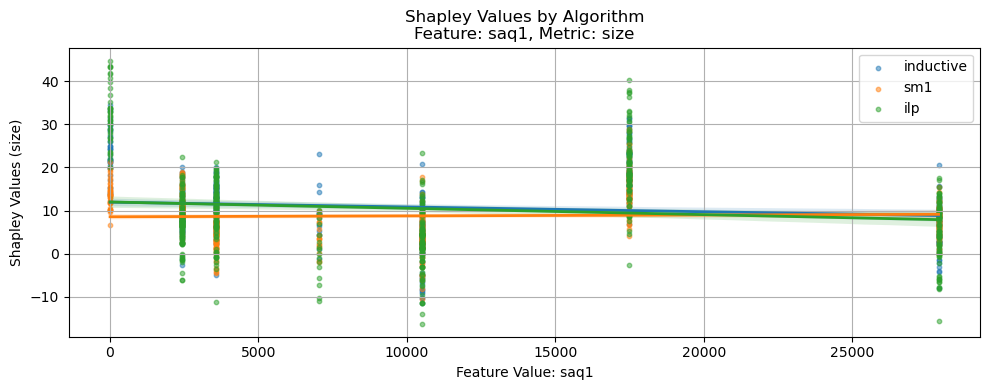

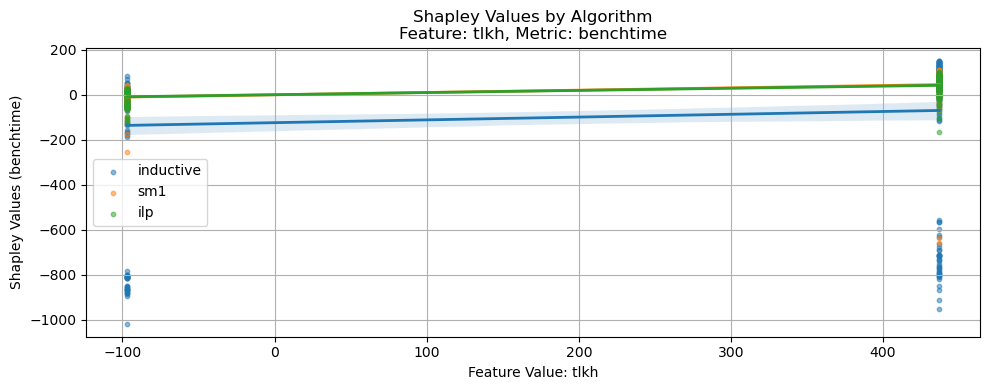

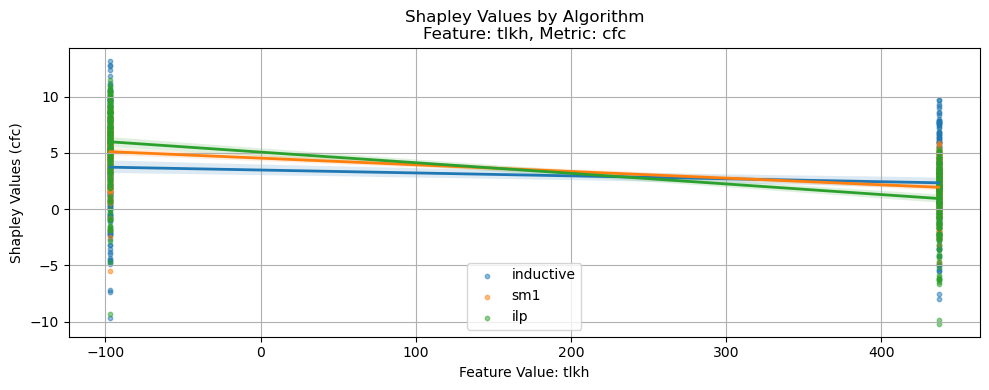

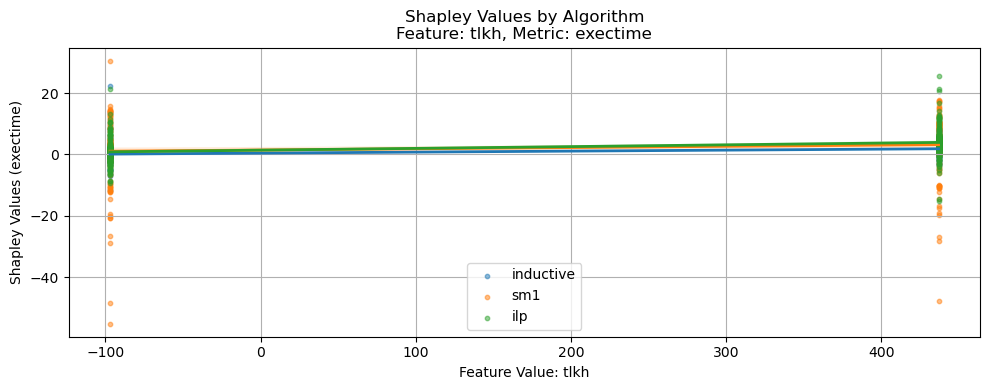

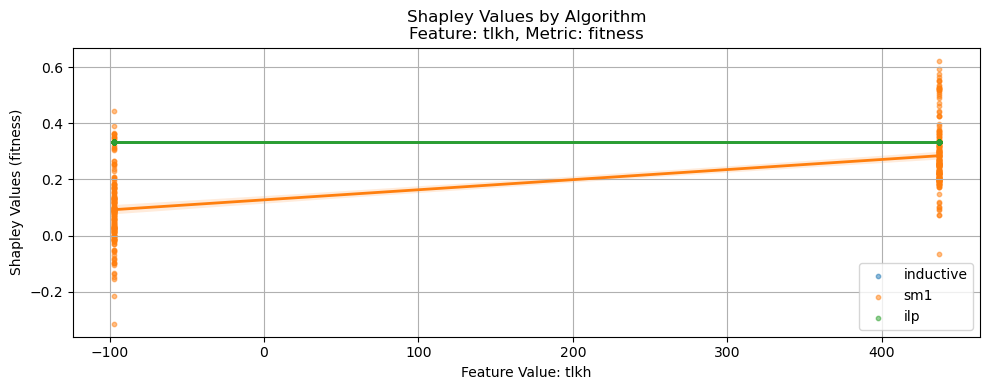

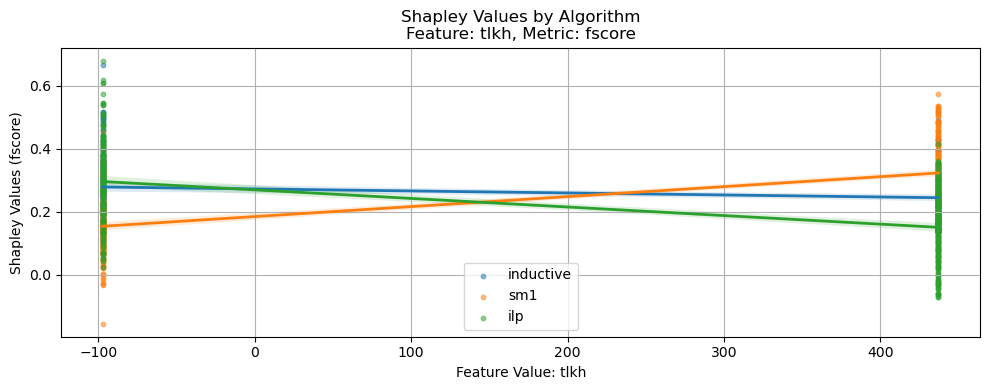

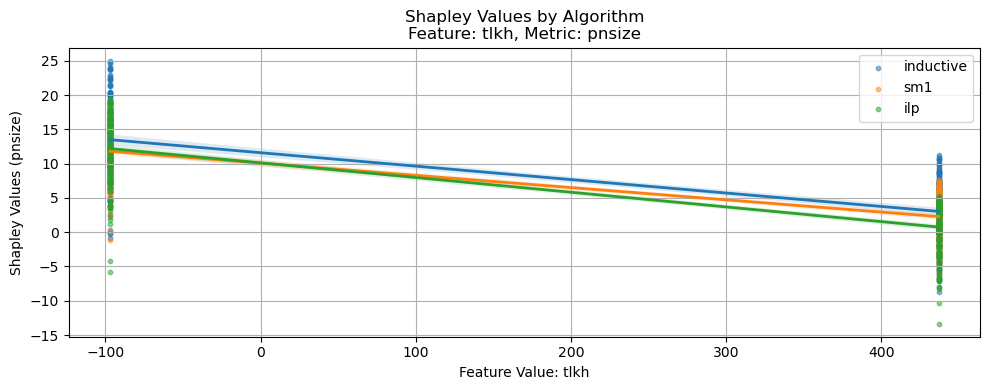

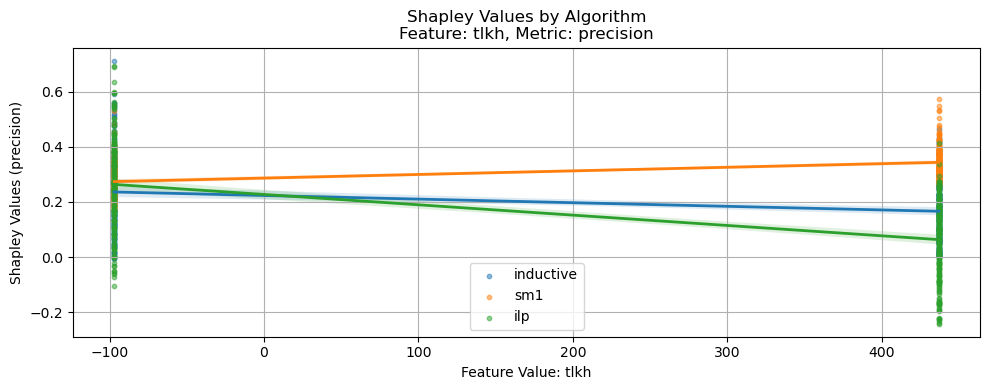

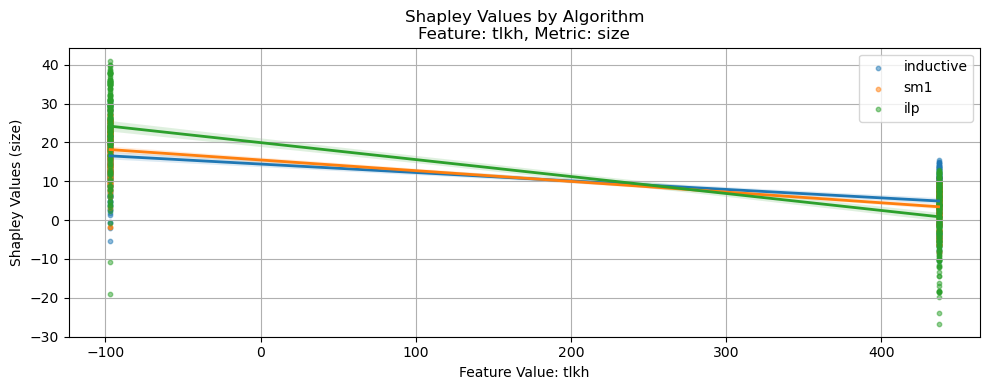

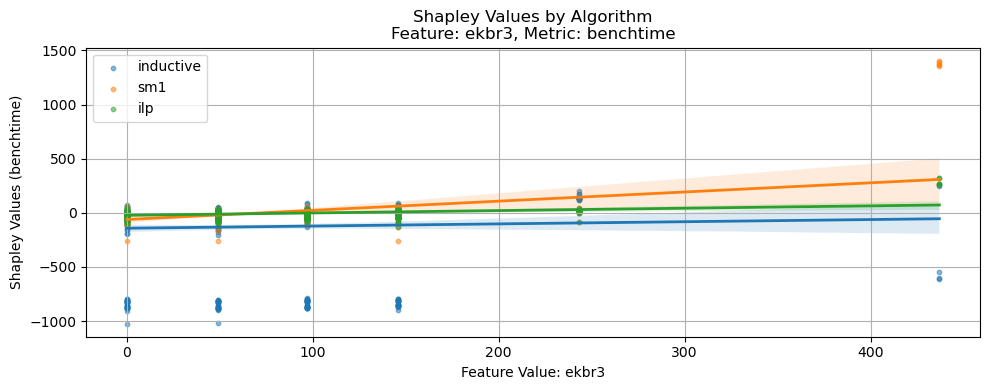

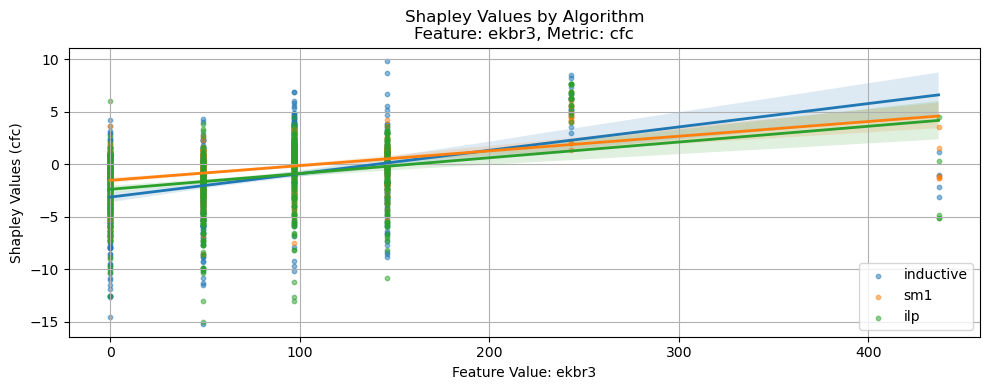

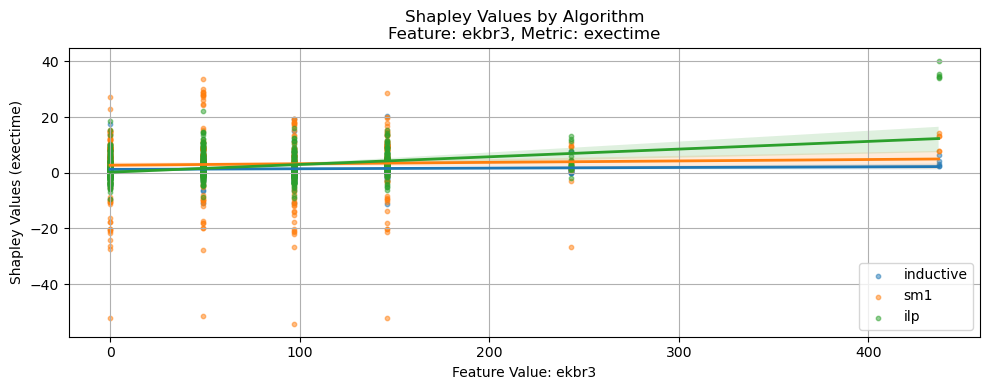

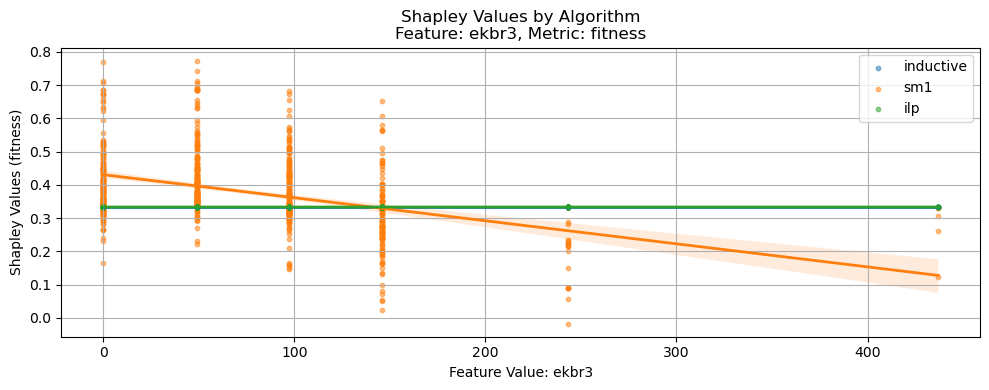

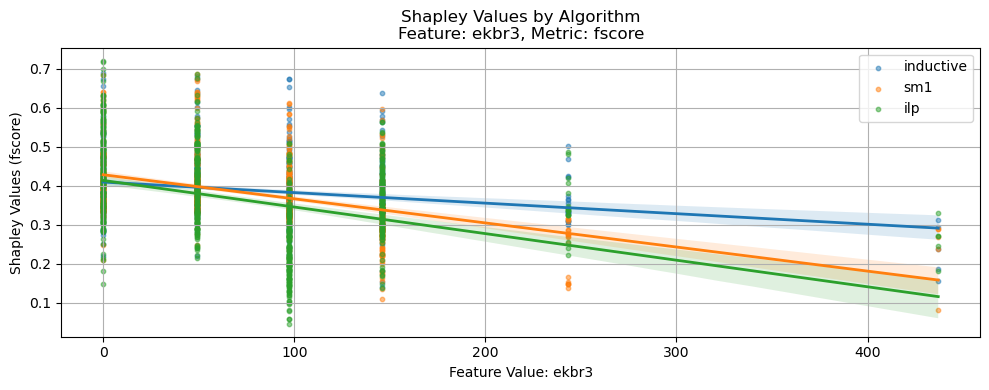

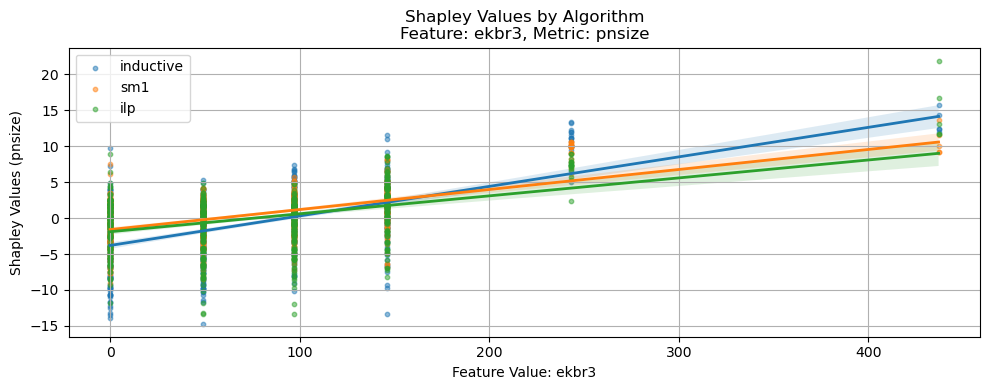

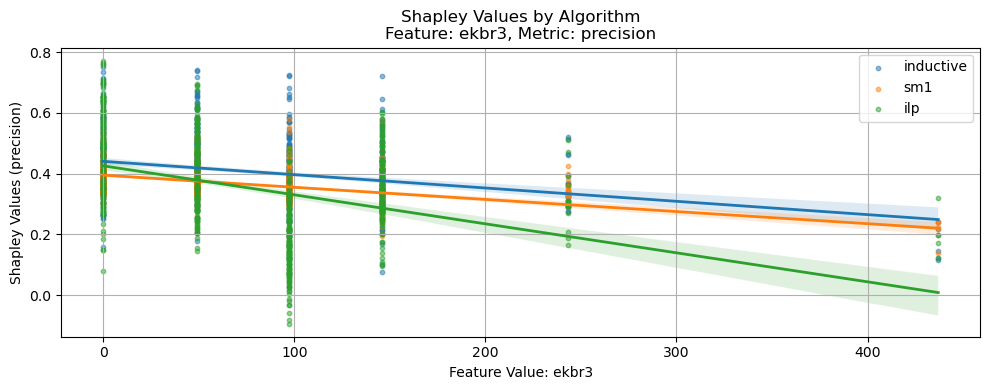

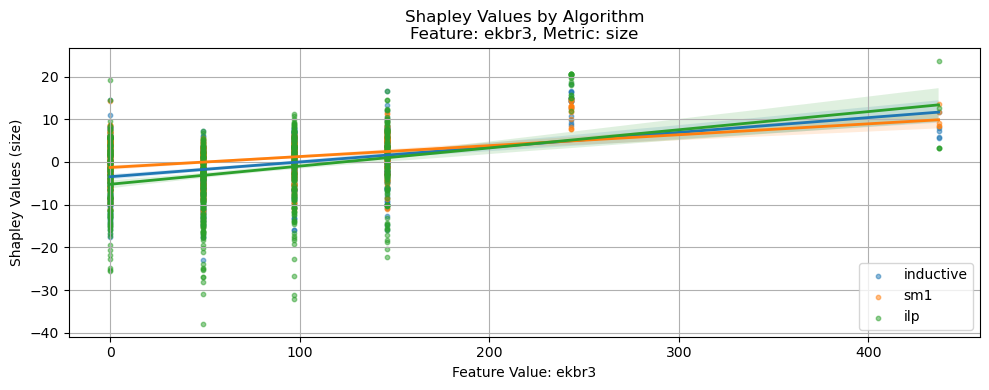

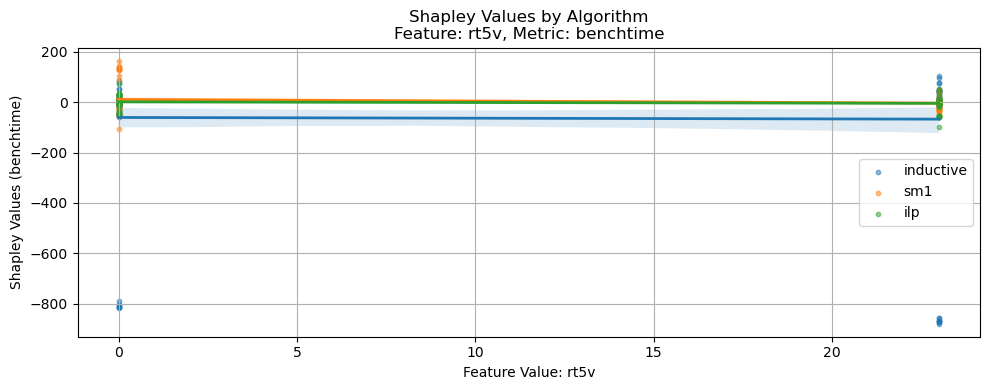

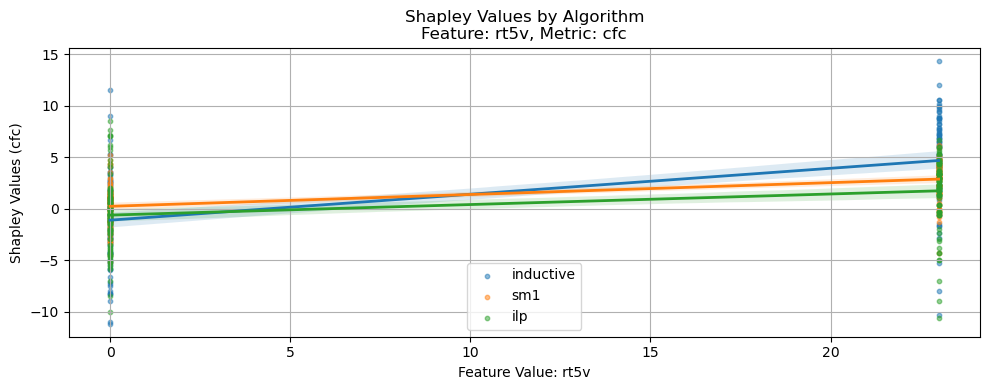

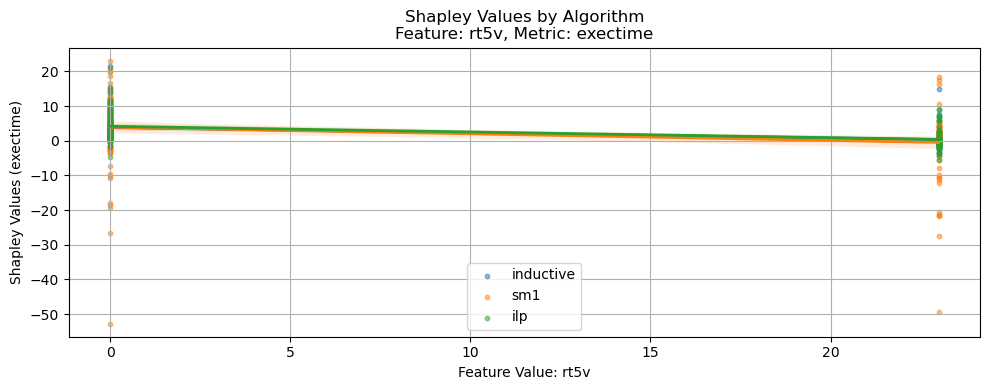

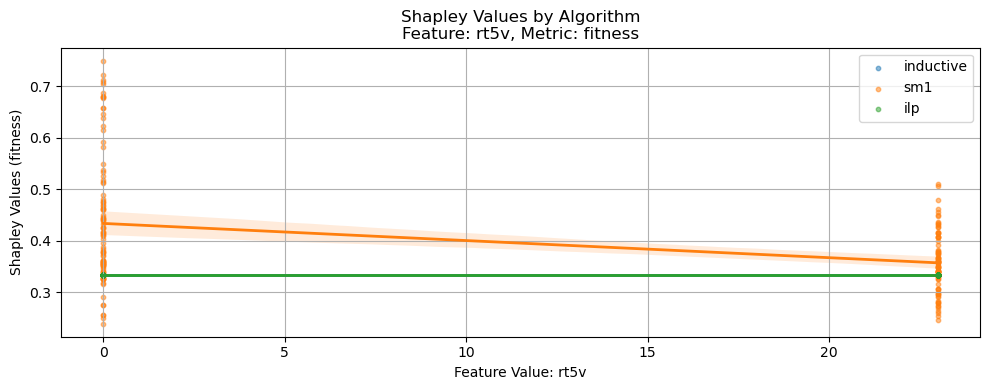

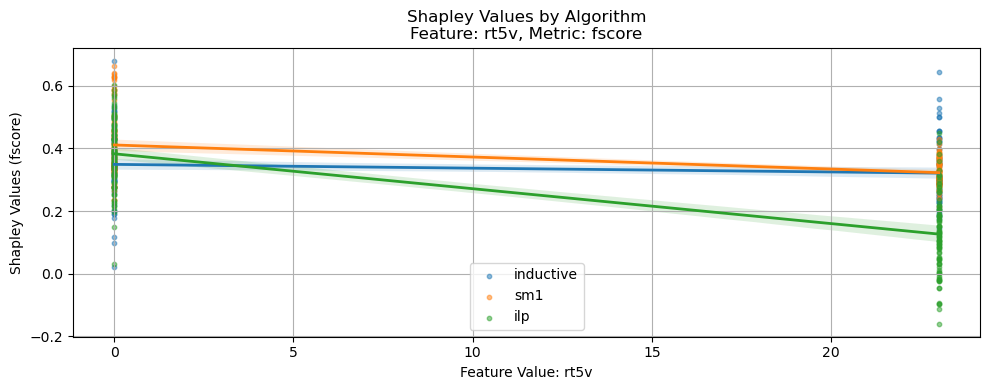

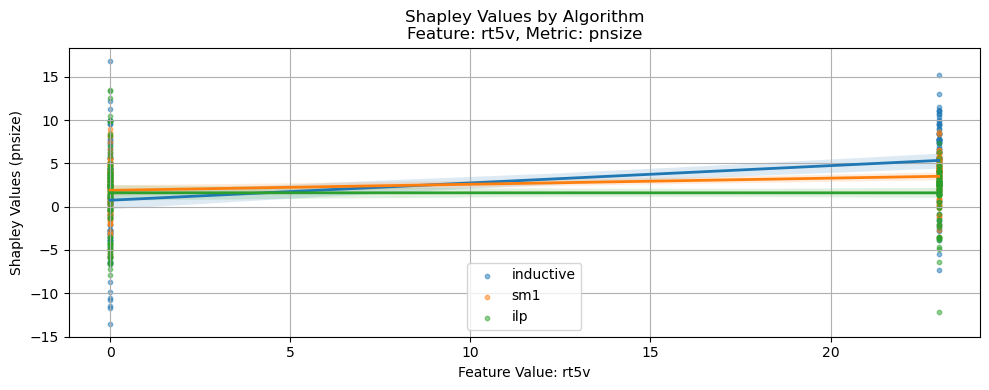

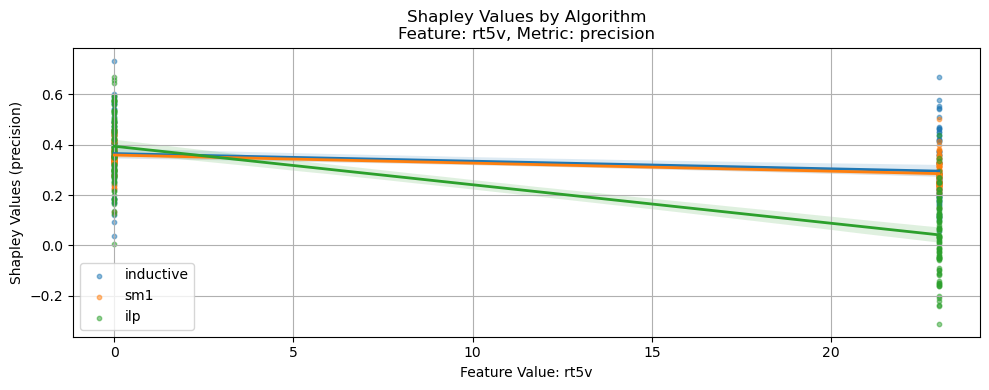

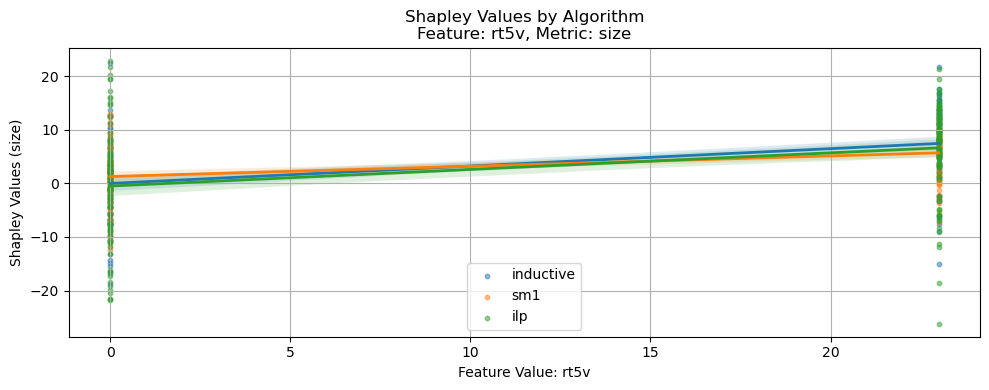

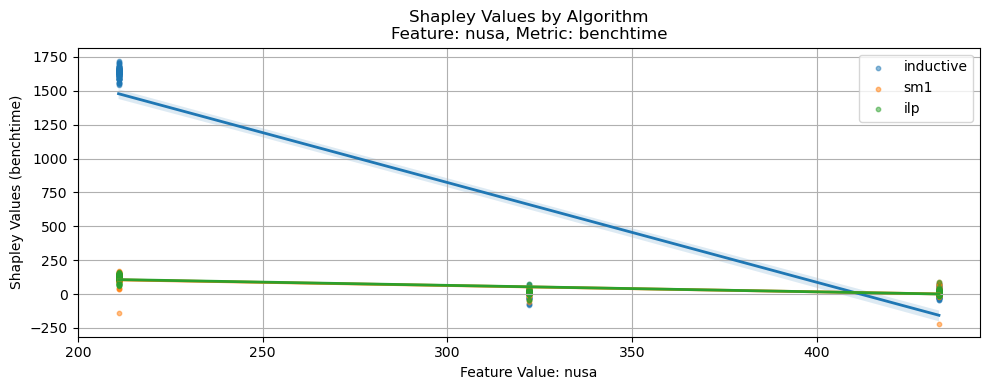

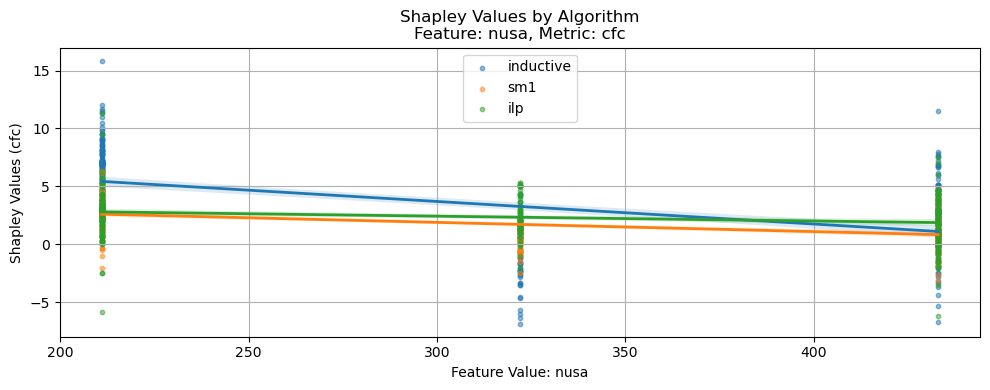

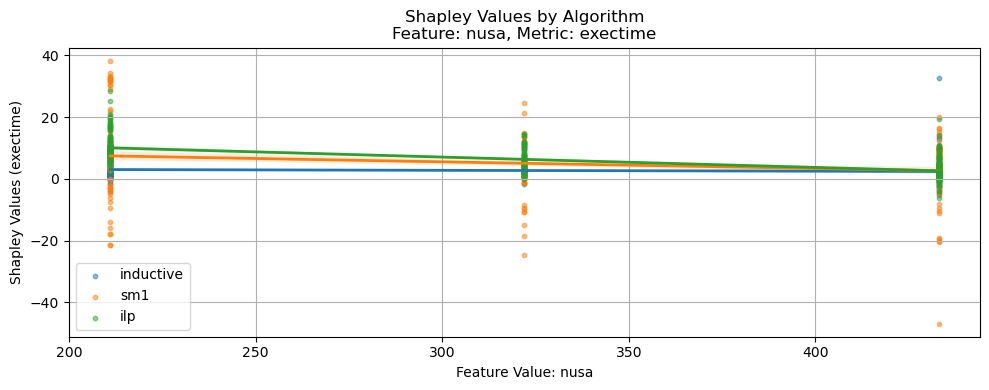

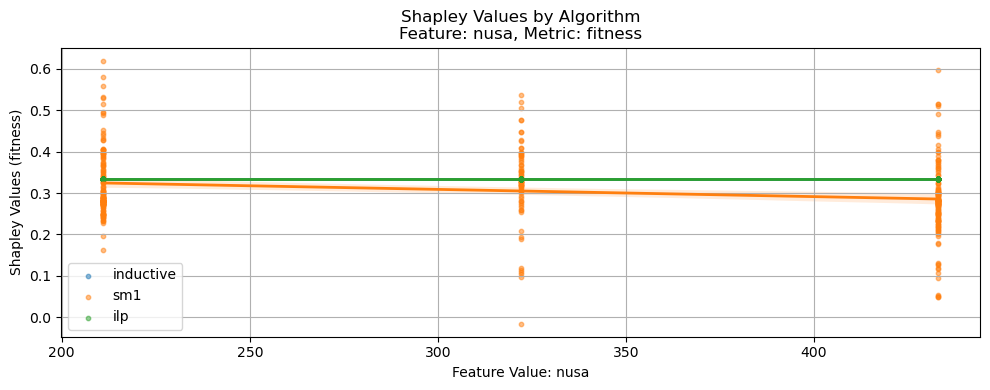

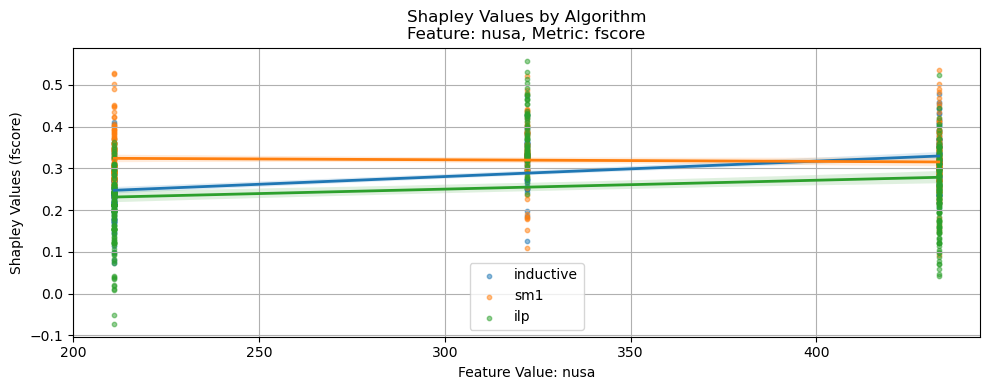

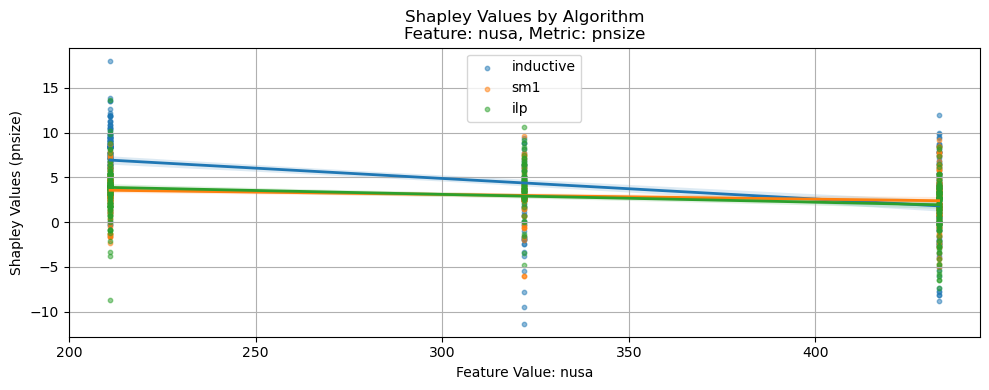

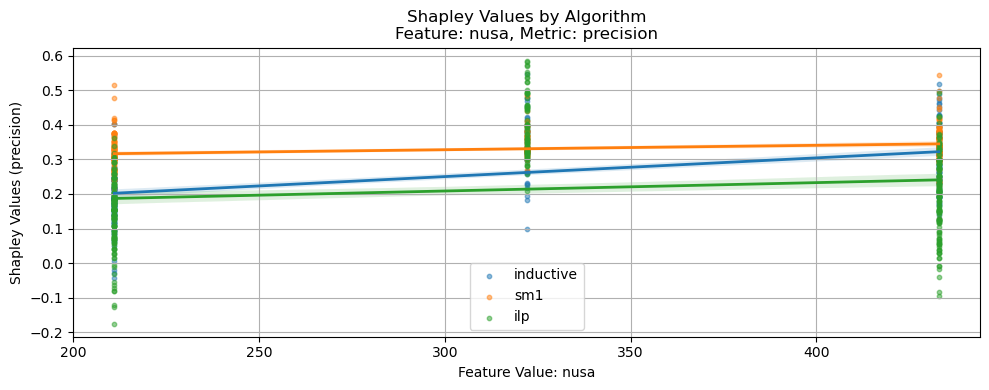

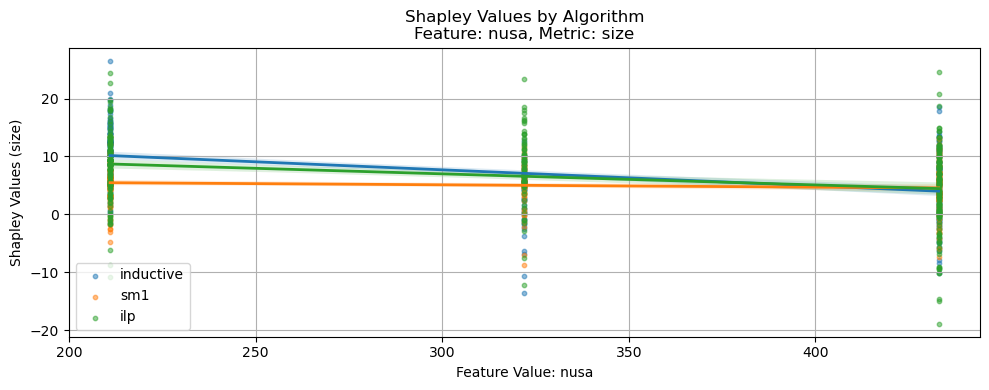

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique values
feature_names = shapley['feature_name'].unique()
algorithm_names = shapley['algorithm'].unique()
metric_names = shapley['metric'].unique()

# Loop over feature_name and metric combinations
for feature_name in feature_names:
    for metric in metric_names:
        plt.figure(figsize=(10, 4))

        # Plot each algorithm with a regression line
        for algorithm in algorithm_names:
            selection = shapley[
                (shapley['feature_name'] == feature_name) &
                (shapley['metric'] == metric) &
                (shapley['algorithm'] == algorithm)
            ]

            # Plot regression line and scatter points
            if not selection.empty:
                sns.regplot(
                    data=selection,
                    x='feature_value',
                    y='shapley_value',
                    label=algorithm,
                    scatter=True,
                    lowess=False,       # Use linear regression
                    scatter_kws={'alpha': 0.5, 's': 10},
                    line_kws={'linewidth': 2}
                )

        plt.xlabel(f'Feature Value: {feature_name}')
        plt.ylabel(f'Shapley Values ({metric})')
        plt.title(f'Shapley Values by Algorithm\nFeature: {feature_name}, Metric: {metric}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

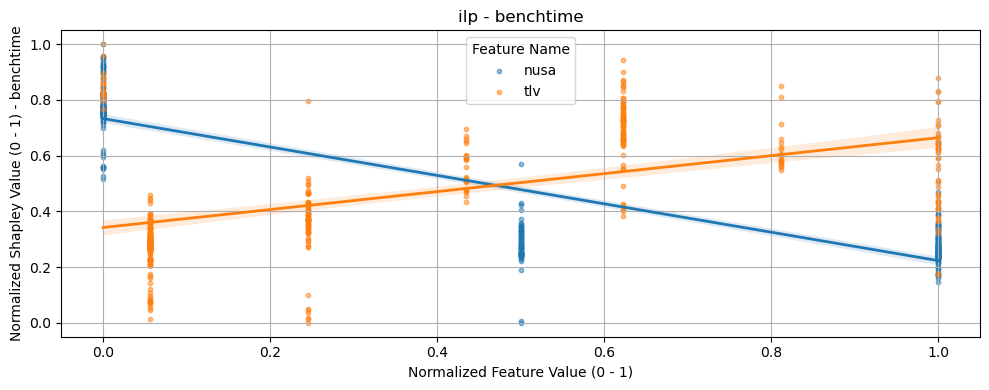

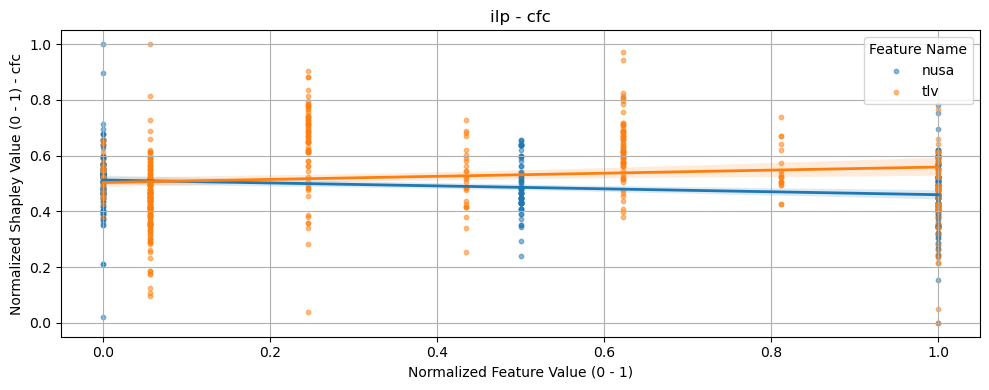

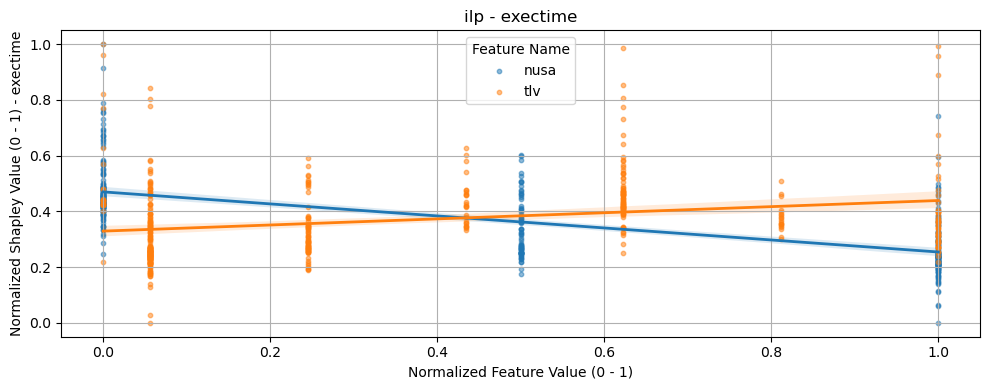

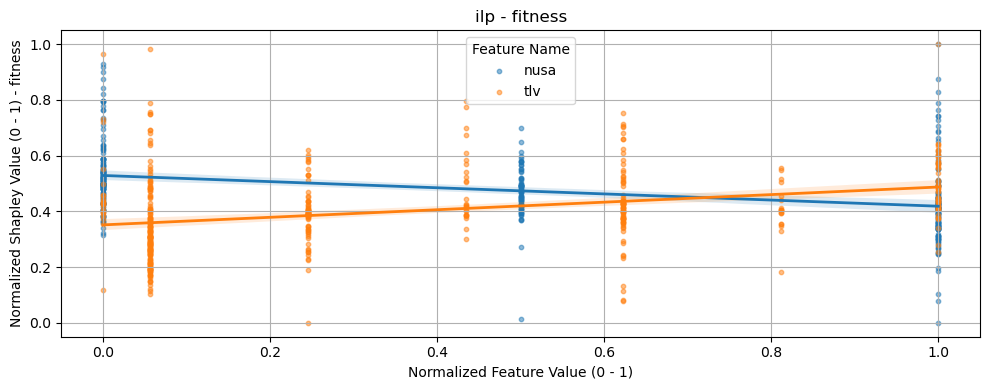

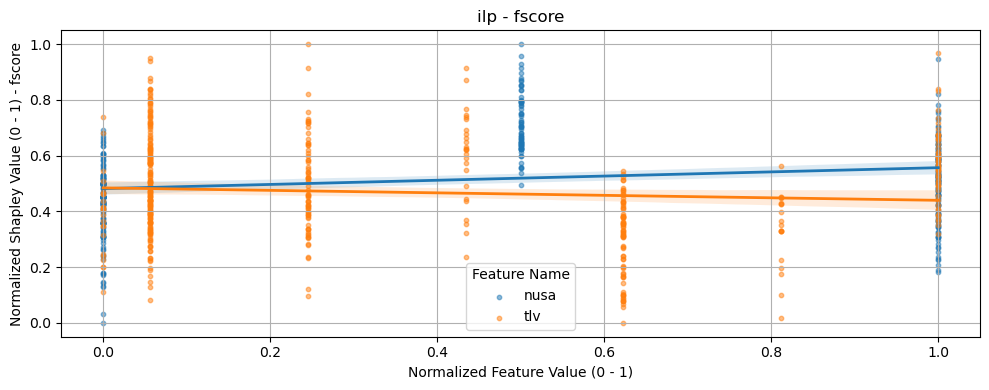

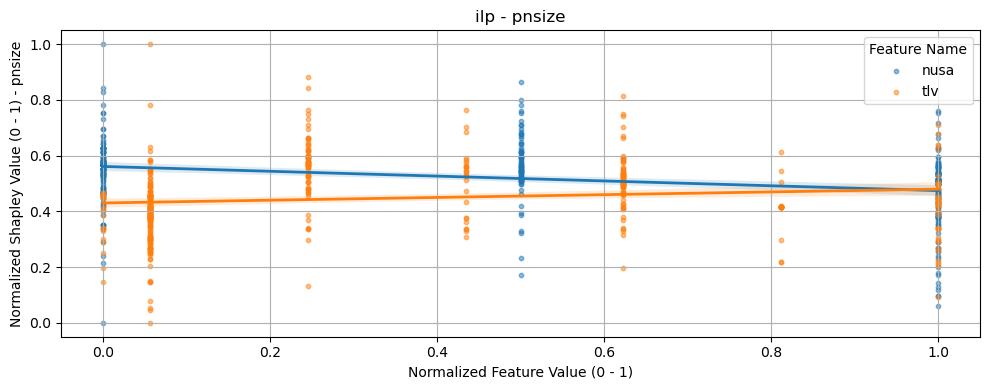

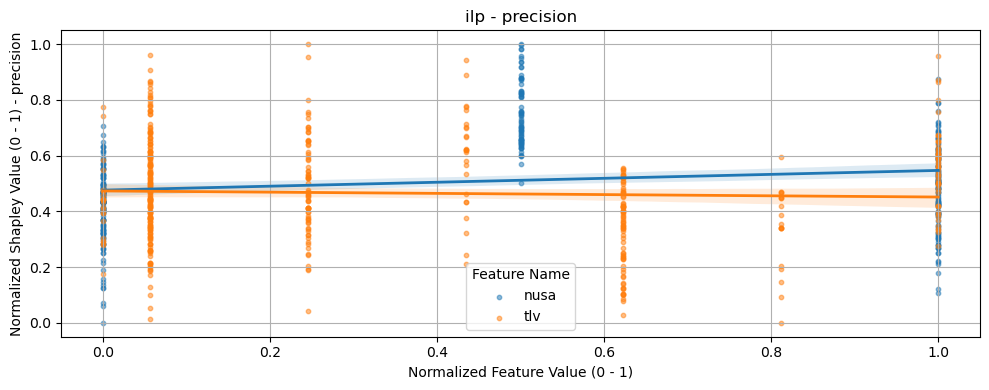

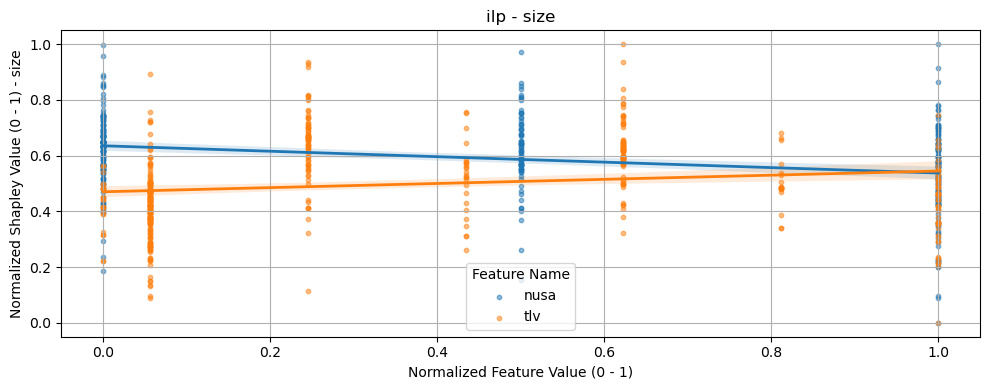

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Get unique values
algorithm_names = ['ilp']  # shapley['algorithm'].unique()
metric_names = shapley['metric'].unique()
feature_names = ['nusa', 'tlv']  # shapley['feature_name'].unique()

# Loop over metric and algorithm combinations
for metric in metric_names:
    for algorithm in algorithm_names:
        plt.figure(figsize=(10, 4))

        # Subset data for this metric and algorithm
        subset = shapley[
            (shapley['metric'] == metric) &
            (shapley['algorithm'] == algorithm)
        ]

        # Plot each feature_name with its own color
        for feature_name in feature_names:
            feature_data = subset[subset['feature_name'] == feature_name].copy()

            if not feature_data.empty:
                # Normalize feature_value (X-axis)
                scaler_x = MinMaxScaler()
                feature_data['normalized_feature_value'] = scaler_x.fit_transform(
                    feature_data[['feature_value']]
                )

                # Normalize shapley_value (Y-axis)
                scaler_y = MinMaxScaler()
                feature_data['normalized_shapley_value'] = scaler_y.fit_transform(
                    feature_data[['shapley_value']]
                )

                sns.regplot(
                    data=feature_data,
                    x='normalized_feature_value',
                    y='normalized_shapley_value',
                    label=feature_name,
                    scatter=True,
                    lowess=False,
                    scatter_kws={'alpha': 0.5, 's': 10},
                    line_kws={'linewidth': 2}
                )

        plt.xlabel('Normalized Feature Value (0 - 1)')
        plt.ylabel(f'Normalized Shapley Value (0 - 1) - {metric}')
        plt.title(f'{algorithm} - {metric}')
        plt.legend(title='Feature Name')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")
np.random.seed(0)

# ============ 1. Linear Regression vs Nonlinearity ============

# Data: y = x^2 + noise
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = X.flatten() ** 2 + np.random.normal(0, 1, size=100)

# Linear regression
model_linear = LinearRegression()
model_linear.fit(X, y)
y_pred = model_linear.predict(X)

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(X, y, alpha=0.5, label='Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Linear Regression')
plt.title("1. Linear Regression Fails on Nonlinear Relationship (y = x²)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============ 2. Linear Regression Misses Feature Interactions ============

# Data: y = x1 * x2 + noise
n = 500
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
y_interact = x1 * x2 + np.random.normal(0, 1, n)

df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y_interact})

# Fit model WITHOUT interaction
model_no_inter = LinearRegression()
model_no_inter.fit(df[['x1', 'x2']], df['y'])
df['y_pred_no_inter'] = model_no_inter.predict(df[['x1', 'x2']])
df['residual_no_inter'] = df['y'] - df['y_pred_no_inter']

# Plot residuals (color = residual)
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x='x1', y='x2', hue='residual_no_inter', palette='coolwarm', alpha=0.7)
plt.title("2. Residuals Show Missed Interaction (True y = x1 * x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Residual", loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()


# ============ 3. Adding Interaction Term Fixes the Model ============

# Add interaction term
df['x1_x2'] = df['x1'] * df['x2']
model_with_inter = LinearRegression()
model_with_inter.fit(df[['x1', 'x2', 'x1_x2']], df['y'])
df['y_pred_with_inter'] = model_with_inter.predict(df[['x1', 'x2', 'x1_x2']])
df['residual_with_inter'] = df['y'] - df['y_pred_with_inter']

# Plot new residuals
plt.figure(figsize=(6, 5))
scatter = sns.scatterplot(data=df, x='x1', y='x2', hue='residual_with_inter', palette='coolwarm', alpha=0.7)
plt.title("3. Residuals After Adding Interaction Term")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(title="Residual", loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()